# US 100B+ Oracle Universe Notebook

This notebook builds a US large-cap equity universe and then generates oracle labels using worst-case adjusted execution assumptions.

Screen requested:
- market cap `>= 100B`
- country = `US`
- exchanges = US exchanges (`NASDAQ`, `NYSE`, `AMEX`)
- exclude ETFs and funds

Oracle label settings requested:
- `YE = [1, 2, 4, 8, 16]`
- `min_profit_pct = 1%`
- buy on `adj_high`
- sell on `adj_low`
- short on `adj_low`
- cover on `adj_high`


In [1]:
import os

import django
import pandas as pd
from django.apps import apps
from IPython.display import display

os.environ.setdefault("DJANGO_ALLOW_ASYNC_UNSAFE", "true")
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "settings")
if not apps.ready:
    django.setup()

from data.historical_prices import load_adjusted_price_frames
from domain.labels.specs import LabelBuildSpec
from features.feature_builders import build_fundamental_change_features, build_price_technical_features
from features.macro import EconomicDataConfig, broadcast_series_to_daily, fetch_economic_data_series
from fmp.models import EconomicIndicatorSeries, Symbol, TreasuryRateSeries
from pipeline.universe_selection import DEFAULT_US_EXCHANGES, resolve_symbol_universe
from workflows.labels import build_oracle_labels

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


In [2]:
APP_CFG = {
    "dates": {
        "start_date": "1900-01-01",
        "end_date": None,
    },
    "universe": {
        "country": "US",
        "exchanges": list(DEFAULT_US_EXCHANGES),
        "min_market_cap": 100_000_000_000.0,
        "exclude_pooled_vehicles": True,
        "size": None,
    },
    "labels": {
        "k_params": {"YE": [1, 2, 4, 8]},
        "min_profit_pct": 0.10,
        "buy_execution": "adj_high",
        "sell_execution": "adj_low",
        "short_execution": "adj_low",
        "cover_execution": "adj_high",
        "trade_dedup_mode": "exact",
        "download_missing_prices": True,
    },
}

APP_CFG

{'dates': {'start_date': '1900-01-01', 'end_date': None},
 'universe': {'country': 'US',
  'exchanges': ['NASDAQ', 'NYSE', 'AMEX'],
  'min_market_cap': 100000000000.0,
  'exclude_pooled_vehicles': True,
  'size': None},
 'labels': {'k_params': {'YE': [1, 2, 4, 8]},
  'min_profit_pct': 0.1,
  'buy_execution': 'adj_high',
  'sell_execution': 'adj_low',
  'short_execution': 'adj_low',
  'cover_execution': 'adj_high',
  'trade_dedup_mode': 'exact',
  'download_missing_prices': True}}

In [3]:
universe = tuple(
    resolve_symbol_universe(
        min_market_cap=float(APP_CFG["universe"]["min_market_cap"]),
        country=str(APP_CFG["universe"]["country"]),
        exchanges=list(APP_CFG["universe"]["exchanges"]),
        exclude_pooled_vehicles=bool(APP_CFG["universe"]["exclude_pooled_vehicles"]),
        limit=APP_CFG["universe"]["size"],
    )
)

if not universe:
    raise ValueError("Universe screen returned no symbols.")

symbol_order = {symbol: idx for idx, symbol in enumerate(universe)}
universe_rows = list(
    Symbol.objects.filter(symbol__in=universe)
    .values("symbol", "company_name", "sector", "industry", "exchange", "country", "market_cap", "payload")
)
universe_df = pd.DataFrame(universe_rows)
if not universe_df.empty:
    universe_df["symbol"] = universe_df["symbol"].astype(str).str.strip().str.upper()
    universe_df["sector"] = universe_df["sector"].fillna("").astype(str).str.strip().replace("", "Unknown")
    universe_df["industry"] = universe_df["industry"].fillna("").astype(str).str.strip().replace("", "Unknown")
    universe_df["sort_order"] = universe_df["symbol"].map(symbol_order)
    universe_df["is_etf"] = universe_df["payload"].apply(
        lambda payload: bool((payload or {}).get("isEtf")) if isinstance(payload, dict) else False
    )
    universe_df["is_fund"] = universe_df["payload"].apply(
        lambda payload: bool((payload or {}).get("isFund")) if isinstance(payload, dict) else False
    )
    universe_df = universe_df.sort_values(["sort_order", "symbol"]).drop(columns=["sort_order", "payload"])

universe_summary_df = pd.DataFrame(
    [
        {
            "country": APP_CFG["universe"]["country"],
            "exchanges": ", ".join(APP_CFG["universe"]["exchanges"]),
            "min_market_cap": float(APP_CFG["universe"]["min_market_cap"]),
            "exclude_pooled_vehicles": bool(APP_CFG["universe"]["exclude_pooled_vehicles"]),
            "resolved_symbol_count": int(len(universe)),
            "sample_symbols": ", ".join(universe[:25]),
        }
    ]
)

display(universe_summary_df)
display(universe_df.head(50))
print(f"Universe size: {len(universe)}")


,country,exchanges,min_market_cap,exclude_pooled_vehicles,resolved_symbol_count,sample_symbols
0,US,"NASDAQ, NYSE, AMEX",1.000000e+11,True,114,"GOOG, AVGO, BRK-B, BRK-A, WMT, LLY, JPM, XOM, ..."


,symbol,company_name,sector,industry,exchange,country,market_cap,is_etf,is_fund
46,GOOG,Alphabet Inc.,Communication Services,Internet Content & Information,NASDAQ,US,3.701803e+12,False,False
11,AVGO,Broadcom Inc.,Technology,Semiconductors,NASDAQ,US,1.639295e+12,False,False
21,BRK-B,Berkshire Hathaway Inc.,Financial Services,Insurance - Diversified,NYSE,US,1.072821e+12,False,False
20,BRK-A,Berkshire Hathaway Inc.,Financial Services,Insurance - Diversified,NYSE,US,1.070225e+12,False,False
112,WMT,Walmart Inc.,Consumer Defensive,Specialty Retail,NASDAQ,US,9.913443e+11,False,False
62,LLY,Eli Lilly and Company,Healthcare,Drug Manufacturers - General,NYSE,US,9.510454e+11,False,False
59,JPM,JPMorgan Chase & Co.,Financial Services,Banks - Diversified,NYSE,US,7.818157e+11,False,False
113,XOM,Exxon Mobil Corporation,Energy,Oil & Gas Integrated,NYSE,US,6.268062e+11,False,False
105,V,Visa Inc.,Financial Services,Financial - Credit Services,NYSE,US,6.092991e+11,False,False
58,JNJ,Johnson & Johnson,Healthcare,Drug Manufacturers - General,NYSE,US,5.846174e+11,False,False


Universe size: 114


In [4]:
price_frames = load_adjusted_price_frames(
    list(universe),
    start_date=APP_CFG["dates"]["start_date"],
    end_date=APP_CFG["dates"]["end_date"],
)

price_diagnostics = []
for symbol in universe:
    frame = price_frames.get(symbol, pd.DataFrame())
    price_diagnostics.append(
        {
            "symbol": symbol,
            "price_rows": int(len(frame)),
            "history_start": frame.index.min().strftime("%Y-%m-%d") if not frame.empty else "",
            "history_end": frame.index.max().strftime("%Y-%m-%d") if not frame.empty else "",
            "has_adj_high": bool("adj_high" in frame.columns),
            "has_adj_low": bool("adj_low" in frame.columns),
            "has_adj_close": bool("adj_close" in frame.columns),
        }
    )

price_diagnostics_df = pd.DataFrame(price_diagnostics)

price_lookup_rows = []
for symbol in universe:
    frame = price_frames.get(symbol, pd.DataFrame())
    if frame.empty:
        continue
    working = frame.reset_index().copy()
    working["symbol"] = symbol
    working["date_text"] = pd.to_datetime(working["date"], errors="coerce").dt.strftime("%Y-%m-%d")
    for row in working.to_dict(orient="records"):
        price_lookup_rows.append(
            {
                "symbol": str(row.get("symbol") or "").strip().upper(),
                "date_text": str(row.get("date_text") or ""),
                "adj_open": row.get("adj_open"),
                "adj_high": row.get("adj_high"),
                "adj_low": row.get("adj_low"),
                "adj_close": row.get("adj_close"),
                "volume": row.get("volume"),
            }
        )

price_lookup_df = pd.DataFrame(price_lookup_rows)
if not price_lookup_df.empty:
    for col in ["adj_open", "adj_high", "adj_low", "adj_close", "volume"]:
        price_lookup_df[col] = pd.to_numeric(price_lookup_df[col], errors="coerce")
    price_lookup_df = price_lookup_df.drop_duplicates(subset=["symbol", "date_text"], keep="last").reset_index(drop=True)
display(price_diagnostics_df.head(50))
print(
    "Symbols with adjusted price history:",
    int((price_diagnostics_df["price_rows"] > 0).sum()),
    "/",
    len(price_diagnostics_df),
)

,symbol,price_rows,history_start,history_end,has_adj_high,has_adj_low,has_adj_close
0,GOOG,5421,2004-08-19,2026-03-06,True,True,True
1,AVGO,4171,2009-08-06,2026-03-06,True,True,True
2,BRK-B,7504,1996-05-09,2026-03-06,True,True,True
3,BRK-A,11587,1980-03-17,2026-03-06,True,True,True
4,WMT,13595,1972-04-03,2026-03-06,True,True,True
5,LLY,14034,1970-07-09,2026-03-06,True,True,True
6,JPM,14373,1969-03-05,2026-03-06,True,True,True
7,XOM,16152,1962-01-02,2026-03-06,True,True,True
8,V,4520,2008-03-19,2026-03-06,True,True,True
9,JNJ,14165,1970-01-02,2026-03-06,True,True,True


Symbols with adjusted price history: 114 / 114


In [5]:
label_spec = LabelBuildSpec(
    k_params=dict(APP_CFG["labels"]["k_params"]),
    min_profit_pct=float(APP_CFG["labels"]["min_profit_pct"]),
    buy_execution=str(APP_CFG["labels"]["buy_execution"]),
    sell_execution=str(APP_CFG["labels"]["sell_execution"]),
    short_execution=str(APP_CFG["labels"]["short_execution"]),
    cover_execution=str(APP_CFG["labels"]["cover_execution"]),
    trade_dedup_mode=str(APP_CFG["labels"]["trade_dedup_mode"]),
    start_date=APP_CFG["dates"]["start_date"],
    end_date=APP_CFG["dates"]["end_date"],
    download_missing_prices=bool(APP_CFG["labels"]["download_missing_prices"]),
)

oracle_result = build_oracle_labels(
    list(universe),
    spec=label_spec,
    price_frames=price_frames,
)

label_df = pd.DataFrame(oracle_result.label_rows)
completed_trades_df = pd.DataFrame(oracle_result.completed_trades)
stats_df = pd.DataFrame([oracle_result.statistics.get("trade_stats", {})])
grouped_stats_df = pd.DataFrame(oracle_result.statistics.get("grouped_trade_stats", []))

if not label_df.empty:
    label_df["date"] = pd.to_datetime(label_df["date"], errors="coerce")
    label_df["entry_date"] = pd.to_datetime(label_df["entry_date"], errors="coerce")
    label_df["exit_date"] = pd.to_datetime(label_df["exit_date"], errors="coerce")
    label_df["trade_return"] = pd.to_numeric(label_df["trade_return"], errors="coerce")
    label_df["hold_days"] = pd.to_numeric(label_df.get("hold_days"), errors="coerce")
    if "trade_duration_days" in label_df.columns:
        label_df["trade_duration_days"] = pd.to_numeric(label_df["trade_duration_days"], errors="coerce")
    label_df["k"] = pd.to_numeric(label_df["k"], errors="coerce").astype("Int64")
    if "trade_id" in label_df.columns:
        label_df["trade_id"] = label_df["trade_id"].astype(str)
    if "event" in label_df.columns:
        label_df["event"] = label_df["event"].fillna("").astype(str).str.strip().str.lower()
    if "action_label" in label_df.columns:
        label_df["action_label"] = label_df["action_label"].fillna("").astype(str).str.strip().str.lower()
    elif "label" in label_df.columns:
        label_df["action_label"] = label_df["label"].fillna("").astype(str).str.strip().str.lower()

if not completed_trades_df.empty:
    completed_trades_df["entry_date"] = pd.to_datetime(completed_trades_df["entry_date"], errors="coerce")
    completed_trades_df["exit_date"] = pd.to_datetime(completed_trades_df["exit_date"], errors="coerce")
    completed_trades_df["ret_dec"] = pd.to_numeric(completed_trades_df["ret_dec"], errors="coerce")
    completed_trades_df["hold_days"] = pd.to_numeric(completed_trades_df["hold_days"], errors="coerce")
    completed_trades_df["k"] = pd.to_numeric(completed_trades_df["k"], errors="coerce").astype("Int64")

display(pd.DataFrame([label_spec.__dict__]))
display(stats_df)
display(grouped_stats_df)
print(f"Label rows: {len(label_df):,}")
print(f"Completed trades: {len(completed_trades_df):,}")


,k_params,solver_mode,min_profit_pct,buy_execution,sell_execution,short_execution,cover_execution,trade_dedup_mode,start_date,end_date,download_missing_prices
0,"{'YE': [1, 2, 4, 8]}",period_top_k,0.1,adj_high,adj_low,adj_low,adj_high,exact,1900-01-01,None,True


,total_trades,symbols_count,long_trades,short_trades,winning_trades,losing_trades,breakeven_trades,win_rate_pct,loss_rate_pct,avg_return_pct,median_return_pct
0,37337,111,23063,14274,37337,0,0,100.0,0.0,27.9459,19.802


,side,freq,k,trades,trade_return_mean_pct,trade_return_std_pct,trade_duration_mean,trade_duration_std,sharpe
0,long,YE,1,3050,59.9763,67.1049,241.6111,89.6924,0.893769
1,long,YE,2,4536,38.8337,37.4681,134.1653,73.1899,1.036448
2,long,YE,4,7346,27.1339,24.6470,72.8533,45.8482,1.100900
3,long,YE,8,8131,21.0907,16.0086,38.5403,26.0451,1.317461
4,short,YE,1,1526,34.9726,15.5009,182.5524,86.4896,2.256170
5,short,YE,2,2765,25.6597,13.3689,105.8575,65.9742,1.919352
6,short,YE,4,4654,20.1557,10.9035,64.5819,43.3736,1.848554
7,short,YE,8,5329,17.9027,9.3080,37.4639,24.9367,1.923380


Label rows: 74,674
Completed trades: 37,337


In [6]:
if completed_trades_df.empty:
    raise ValueError("No completed trades were generated for the current config.")

trade_summary_df = (
    completed_trades_df.groupby(["side", "freq", "k"], as_index=False)
    .agg(
        trades=("symbol", "count"),
        avg_return_pct=("ret_dec", lambda series: series.mean() * 100.0),
        median_return_pct=("ret_dec", lambda series: series.median() * 100.0),
        avg_hold_days=("hold_days", "mean"),
    )
    .sort_values(["side", "freq", "k"])
    .reset_index(drop=True)
)

top_trades_df = completed_trades_df.sort_values("ret_dec", ascending=False).head(25).reset_index(drop=True)
recent_trades_df = completed_trades_df.sort_values(["entry_date", "symbol", "side"]).tail(25).reset_index(drop=True)

display(trade_summary_df)
display(top_trades_df)
display(recent_trades_df)
display(label_df.head(25))


,side,freq,k,trades,avg_return_pct,median_return_pct,avg_hold_days
0,long,YE,1,3050,59.976289,43.951700,241.611148
1,long,YE,2,4536,38.833743,28.752485,134.165344
2,long,YE,4,7346,27.133901,19.948825,72.853253
3,long,YE,8,8131,21.090722,16.090060,38.540278
4,short,YE,1,1526,34.972575,32.131856,182.552425
5,short,YE,2,2765,25.659717,21.945117,105.857505
6,short,YE,4,4654,20.155667,16.388201,64.581865
7,short,YE,8,5329,17.902733,14.796120,37.463877


,symbol,side,freq,k,entry_date,exit_date,entry_px,exit_px,ret_dec,hold_days
0,QCOM,long,YE,1,1999-01-04,1999-12-31,2.1900,52.0600,22.771689,361
1,APP,long,YE,1,2024-01-04,2024-12-06,38.4200,378.0000,8.838626,337
2,APP,long,YE,2,2024-01-04,2024-12-05,38.4200,370.3500,8.639511,336
3,MO,long,YE,1,1989-01-10,1989-10-16,0.0192,0.1385,6.208267,279
4,QCOM,long,YE,2,1999-01-04,1999-08-26,2.1900,14.5500,5.643836,234
5,AMD,long,YE,1,2016-02-16,2016-12-27,1.9000,11.6000,5.105263,315
6,CRWD,long,YE,1,2020-03-16,2020-12-24,36.0000,219.2800,5.091111,283
7,BKNG,long,YE,1,2001-01-02,2001-07-03,9.0400,54.0200,4.975664,182
8,HD,long,YE,1,1982-01-04,1982-12-09,0.0303,0.1763,4.827822,339
9,CRWD,long,YE,2,2020-03-17,2020-12-24,38.3000,219.2800,4.725326,282


,symbol,side,freq,k,entry_date,exit_date,entry_px,exit_px,ret_dec,hold_days
0,SCHW,short,YE,1,2026-02-09,2026-02-23,104.4300,93.9200,0.100642,14
1,ANET,short,YE,4,2026-02-10,2026-03-03,141.8000,126.8300,0.105571,21
2,BX,short,YE,2,2026-02-10,2026-03-06,131.2400,113.0000,0.138982,24
3,MU,long,YE,2,2026-02-10,2026-02-25,382.7900,423.0000,0.105045,15
4,PANW,short,YE,4,2026-02-10,2026-02-24,164.3000,147.5200,0.102130,14
5,APP,short,YE,4,2026-02-11,2026-02-13,438.1800,391.8500,0.105733,2
6,CRWD,short,YE,4,2026-02-13,2026-02-24,412.5800,360.9000,0.125261,11
7,LOW,short,YE,2,2026-02-13,2026-03-06,282.1500,252.2500,0.105972,21
8,NFLX,long,YE,1,2026-02-13,2026-03-05,77.1800,98.1000,0.271055,20
9,APP,long,YE,2,2026-02-17,2026-03-06,388.1100,491.2800,0.265827,17


,date,event,label,action_label,market_position,symbol,trade_id,direction_label,trade_return,hold_days,trade_duration_days,side,freq,k,horizon,entry_date,exit_date,entry_px,exit_px,ret_pct
0,2004-09-03,entry,buy,buy,1,GOOG,T|GOOG|E20040903|X20041102|Slong|HYE_k1,1,0.904382,60,60,long,YE,1,YE_k1,2004-09-03,2004-11-02,2.5100,4.7800,90.44%
1,2004-11-02,exit,sell,sell,0,GOOG,T|GOOG|E20040903|X20041102|Slong|HYE_k1,1,0.904382,60,60,long,YE,1,YE_k1,2004-09-03,2004-11-02,2.5100,4.7800,90.44%
2,2005-03-14,entry,buy,buy,1,GOOG,T|GOOG|E20050314|X20051223|Slong|HYE_k1,1,1.403628,284,284,long,YE,1,YE_k1,2005-03-14,2005-12-23,4.4100,10.6000,140.36%
3,2005-12-23,exit,sell,sell,0,GOOG,T|GOOG|E20050314|X20051223|Slong|HYE_k1,1,1.403628,284,284,long,YE,1,YE_k1,2005-03-14,2005-12-23,4.4100,10.6000,140.36%
4,2006-03-17,entry,buy,buy,1,GOOG,T|GOOG|E20060317|X20061122|Slong|HYE_k1,1,0.480473,250,250,long,YE,1,YE_k1,2006-03-17,2006-11-22,8.4500,12.5100,48.05%
5,2006-11-22,exit,sell,sell,0,GOOG,T|GOOG|E20060317|X20061122|Slong|HYE_k1,1,0.480473,250,250,long,YE,1,YE_k1,2006-03-17,2006-11-22,8.4500,12.5100,48.05%
6,2007-03-05,entry,buy,buy,1,GOOG,T|GOOG|E20070305|X20071106|Slong|HYE_k1,1,0.626134,246,246,long,YE,1,YE_k1,2007-03-05,2007-11-06,11.0200,17.9200,62.61%
7,2007-11-06,exit,sell,sell,0,GOOG,T|GOOG|E20070305|X20071106|Slong|HYE_k1,1,0.626134,246,246,long,YE,1,YE_k1,2007-03-05,2007-11-06,11.0200,17.9200,62.61%
8,2008-01-02,entry,short,short,-1,GOOG,T|GOOG|E20080102|X20081121|Sshort|HYE_k1,0,0.602388,324,324,short,YE,1,YE_k1,2008-01-02,2008-11-21,16.7500,6.6600,60.24%
9,2008-11-21,exit,cover,cover,0,GOOG,T|GOOG|E20080102|X20081121|Sshort|HYE_k1,0,0.602388,324,324,short,YE,1,YE_k1,2008-01-02,2008-11-21,16.7500,6.6600,60.24%


In [7]:
label_df.head()

,date,event,label,action_label,market_position,symbol,trade_id,direction_label,trade_return,hold_days,trade_duration_days,side,freq,k,horizon,entry_date,exit_date,entry_px,exit_px,ret_pct
0,2004-09-03,entry,buy,buy,1,GOOG,T|GOOG|E20040903|X20041102|Slong|HYE_k1,1,0.904382,60,60,long,YE,1,YE_k1,2004-09-03,2004-11-02,2.5100,4.7800,90.44%
1,2004-11-02,exit,sell,sell,0,GOOG,T|GOOG|E20040903|X20041102|Slong|HYE_k1,1,0.904382,60,60,long,YE,1,YE_k1,2004-09-03,2004-11-02,2.5100,4.7800,90.44%
2,2005-03-14,entry,buy,buy,1,GOOG,T|GOOG|E20050314|X20051223|Slong|HYE_k1,1,1.403628,284,284,long,YE,1,YE_k1,2005-03-14,2005-12-23,4.4100,10.6000,140.36%
3,2005-12-23,exit,sell,sell,0,GOOG,T|GOOG|E20050314|X20051223|Slong|HYE_k1,1,1.403628,284,284,long,YE,1,YE_k1,2005-03-14,2005-12-23,4.4100,10.6000,140.36%
4,2006-03-17,entry,buy,buy,1,GOOG,T|GOOG|E20060317|X20061122|Slong|HYE_k1,1,0.480473,250,250,long,YE,1,YE_k1,2006-03-17,2006-11-22,8.4500,12.5100,48.05%


In [8]:
label_df.describe()

,date,market_position,direction_label,trade_return,hold_days,trade_duration_days,k,entry_date,exit_date
count,74674,74674.000000,74674.000000,74674.000000,74674.000000,74674.000000,74674.0,74674,74674
mean,2000-02-20 18:57:31.996678,0.117698,0.617698,0.279459,87.460669,87.460669,4.683236,2000-01-08 01:25:51.094089,2000-04-04 12:29:12.899268
min,1962-01-02 00:00:00,-1.000000,0.000000,0.100000,1.000000,1.000000,1.0,1962-01-02 00:00:00,1962-01-29 00:00:00
25%,1987-03-11 06:00:00,0.000000,0.000000,0.137755,31.000000,31.000000,2.0,1987-01-02 00:00:00,1987-05-01 00:00:00
50%,2001-01-11 00:00:00,0.000000,1.000000,0.198020,59.000000,59.000000,4.0,2001-01-02 00:00:00,2001-02-21 00:00:00
75%,2014-04-14 00:00:00,1.000000,1.000000,0.317979,116.000000,116.000000,8.0,2014-02-06 00:00:00,2014-07-22 00:00:00
max,2026-03-06 00:00:00,1.000000,1.000000,22.771690,364.000000,364.000000,8.0,2026-03-02 00:00:00,2026-03-06 00:00:00
std,NaN,0.697247,0.485953,0.299454,80.035968,80.035968,2.680764,NaN,NaN


In [9]:
from analysis.oracle_entry_exit_dataset import (
    ENTRY_NUMERIC_COLS,
    EXIT_NUMERIC_COLS,
    STATE_NUMERIC_COLS,
    build_oracle_entry_exit_frames,
)
from features.financial_growth_features import build_financial_growth_features
from features.section_utils import prime_section_record_cache

trade_pair_df, state_df = build_oracle_entry_exit_frames(
    universe_df=universe_df,
    label_df=label_df,
    completed_trades_df=completed_trades_df,
    price_lookup_df=price_lookup_df,
)

unique_symbols = sorted([str(value).strip().upper() for value in state_df["symbol"].dropna().unique() if str(value).strip()])
symbol_obj_rows = list(Symbol.objects.filter(symbol__in=unique_symbols).only("id", "symbol"))
symbol_obj_map = {str(item.symbol).strip().upper(): item for item in symbol_obj_rows}
prime_section_record_cache(symbol_obj_rows, ["key_metrics", "ratios", "financial_growth"])

fundamental_frames = []
fundamental_source_rows = []
technical_frames = []
technical_source_rows = []
for symbol in unique_symbols:
    symbol_obj = symbol_obj_map.get(symbol)
    if symbol_obj is None:
        continue

    symbol_date_values = state_df.loc[state_df["symbol"] == symbol, "date_text"].dropna().astype(str).unique().tolist()
    symbol_dates = pd.DatetimeIndex(pd.to_datetime(symbol_date_values, errors="coerce")).dropna().normalize().unique().sort_values()
    if len(symbol_dates) == 0:
        continue

    target_index = pd.MultiIndex.from_arrays(
        [symbol_dates, [symbol] * len(symbol_dates)],
        names=["date", "symbol"],
    )

    df_prices_symbol = price_frames.get(symbol, pd.DataFrame()).copy()
    if not df_prices_symbol.empty and "adj_close" in df_prices_symbol.columns and "close" not in df_prices_symbol.columns:
        df_prices_symbol = df_prices_symbol.rename(columns={"adj_close": "close"})

    merged_symbol_features = pd.DataFrame(index=target_index)
    selected_feature_cols = []

    technical_built = build_price_technical_features(symbol, df_prices_symbol) if not df_prices_symbol.empty else None
    if technical_built is not None and not technical_built.df.empty and technical_built.feature_cols:
        technical_aligned = technical_built.df.reindex(target_index)
        merged_symbol_features = merged_symbol_features.join(
            technical_aligned[technical_built.feature_cols],
            how="left",
        )
        selected_feature_cols.extend(list(technical_built.feature_cols))

    fundamental_built = build_fundamental_change_features(
        symbol_obj,
        target_index,
        df_prices=df_prices_symbol if not df_prices_symbol.empty else None,
    )
    if not fundamental_built.df.empty and fundamental_built.feature_cols:
        merged_symbol_features = merged_symbol_features.join(
            fundamental_built.df[fundamental_built.feature_cols],
            how="left",
        )
        selected_feature_cols.extend(list(fundamental_built.feature_cols))

    financial_growth_built = build_financial_growth_features(symbol_obj, target_index)
    if not financial_growth_built.df.empty and financial_growth_built.feature_cols:
        merged_symbol_features = merged_symbol_features.join(
            financial_growth_built.df[financial_growth_built.feature_cols],
            how="left",
        )
        selected_feature_cols.extend(list(financial_growth_built.feature_cols))

    selected_feature_cols = list(dict.fromkeys(selected_feature_cols))
    if not selected_feature_cols:
        continue

    technical_source_rows.append(
        {
            "symbol": symbol,
            "technical_cols": sum(1 for col in selected_feature_cols if str(col).startswith("px__")),
        }
    )
    fundamental_source_rows.append(
        {
            "symbol": symbol,
            "feature_cols": len(selected_feature_cols),
            "technical_cols": sum(1 for col in selected_feature_cols if str(col).startswith("px__")),
            "key_metrics_cols": sum(1 for col in selected_feature_cols if str(col).startswith("km__")),
            "ratios_cols": sum(1 for col in selected_feature_cols if str(col).startswith("rt__")),
            "financial_growth_cols": sum(1 for col in selected_feature_cols if str(col).startswith("fg__")),
        }
    )
    symbol_feature_df = merged_symbol_features[selected_feature_cols].reset_index()
    symbol_feature_df["date_text"] = pd.to_datetime(symbol_feature_df["date"], errors="coerce").dt.strftime("%Y-%m-%d")
    fundamental_frames.append(symbol_feature_df[["symbol", "date_text", *selected_feature_cols]])

if fundamental_frames:
    combined_symbol_feature_df = pd.concat(fundamental_frames, ignore_index=True)
    TECHNICAL_FEATURE_COLS = sorted(
        [
            col for col in combined_symbol_feature_df.columns
            if str(col).startswith("px__")
        ]
    )
    TECHNICAL_FEATURE_COLS = [
        col for col in TECHNICAL_FEATURE_COLS
        if col not in {"px__adj_open", "px__adj_high", "px__adj_low", "px__adj_close"}
    ]
    FUNDAMENTAL_FEATURE_COLS = sorted(
        [
            col for col in combined_symbol_feature_df.columns
            if str(col).startswith(("km__", "rt__", "fg__"))
        ]
    )
    symbol_feature_lookup_df = combined_symbol_feature_df[["symbol", "date_text", *TECHNICAL_FEATURE_COLS, *FUNDAMENTAL_FEATURE_COLS]].copy()
    for col in TECHNICAL_FEATURE_COLS + FUNDAMENTAL_FEATURE_COLS:
        symbol_feature_lookup_df[col] = pd.to_numeric(symbol_feature_lookup_df[col], errors="coerce")
else:
    TECHNICAL_FEATURE_COLS = []
    FUNDAMENTAL_FEATURE_COLS = []
    symbol_feature_lookup_df = pd.DataFrame(columns=["symbol", "date_text"])

KM_FEATURE_COLS = [col for col in FUNDAMENTAL_FEATURE_COLS if str(col).startswith("km__")]
RATIO_FEATURE_COLS = [col for col in FUNDAMENTAL_FEATURE_COLS if str(col).startswith("rt__")]
FG_FEATURE_COLS = [col for col in FUNDAMENTAL_FEATURE_COLS if str(col).startswith("fg__")]

all_macro_dates = pd.to_datetime(
    pd.concat(
        [
            state_df["date_text"],
            trade_pair_df["entry_date_text"],
            trade_pair_df["exit_date_text"],
        ],
        axis=0,
        ignore_index=True,
    ),
    errors="coerce",
).dropna()
if len(all_macro_dates) > 0:
    macro_start = all_macro_dates.min().date().isoformat()
    macro_end = all_macro_dates.max().date().isoformat()
else:
    macro_start = None
    macro_end = None

if macro_start and macro_end:
    economic_series_codes = tuple(str(code) for code in EconomicIndicatorSeries.objects.order_by("code").values_list("code", flat=True))
    treasury_series_codes = tuple(str(code) for code in TreasuryRateSeries.objects.order_by("code").values_list("code", flat=True))

    economic_df = fetch_economic_data_series(
        api_key="",
        start_date=macro_start,
        end_date=macro_end,
        config=EconomicDataConfig(
            economic_indicator_series=economic_series_codes,
            include_treasury_rates=False,
        ),
    )
    treasury_df = fetch_economic_data_series(
        api_key="",
        start_date=macro_start,
        end_date=macro_end,
        config=EconomicDataConfig(
            economic_indicator_series=treasury_series_codes,
            include_treasury_rates=False,
        ),
    )
else:
    economic_df = pd.DataFrame()
    treasury_df = pd.DataFrame()

macro_target_index = pd.MultiIndex.from_arrays(
    [pd.to_datetime(state_df["date_text"], errors="coerce"), state_df["symbol"].astype(str)],
    names=["date", "symbol"],
)

economic_daily = broadcast_series_to_daily(economic_df, macro_target_index) if not economic_df.empty else pd.DataFrame(index=macro_target_index)
treasury_daily = broadcast_series_to_daily(treasury_df, macro_target_index) if not treasury_df.empty else pd.DataFrame(index=macro_target_index)
ECONOMIC_FEATURE_COLS = [str(col) for col in list(economic_daily.columns)]
TREASURY_FEATURE_COLS = [str(col) for col in list(treasury_daily.columns)]
MACRO_FEATURE_COLS = ECONOMIC_FEATURE_COLS + TREASURY_FEATURE_COLS

if MACRO_FEATURE_COLS:
    macro_lookup_df = pd.concat([economic_daily, treasury_daily], axis=1).reset_index()
    macro_lookup_df["date_text"] = pd.to_datetime(macro_lookup_df["date"], errors="coerce").dt.strftime("%Y-%m-%d")
    macro_lookup_df = macro_lookup_df[["date_text", *MACRO_FEATURE_COLS]].copy()
    for col in MACRO_FEATURE_COLS:
        macro_lookup_df[col] = pd.to_numeric(macro_lookup_df[col], errors="coerce")
    macro_lookup_df = macro_lookup_df.groupby("date_text", as_index=False).last()
else:
    macro_lookup_df = pd.DataFrame(columns=["date_text"])

state_df = state_df.merge(symbol_feature_lookup_df, on=["symbol", "date_text"], how="left")
for col in TECHNICAL_FEATURE_COLS + FUNDAMENTAL_FEATURE_COLS:
    state_df[col] = pd.to_numeric(state_df[col], errors="coerce")
state_df = state_df.merge(macro_lookup_df, on="date_text", how="left")
for col in MACRO_FEATURE_COLS:
    state_df[col] = pd.to_numeric(state_df[col], errors="coerce")

entry_symbol_feature_lookup_df = symbol_feature_lookup_df.rename(
    columns={
        "date_text": "entry_date_text",
        **{col: f"entry_{col}" for col in TECHNICAL_FEATURE_COLS + FUNDAMENTAL_FEATURE_COLS},
    }
)
exit_symbol_feature_lookup_df = symbol_feature_lookup_df.rename(
    columns={
        "date_text": "exit_date_text",
        **{col: f"exit_{col}" for col in TECHNICAL_FEATURE_COLS + FUNDAMENTAL_FEATURE_COLS},
    }
)
trade_pair_df = trade_pair_df.merge(entry_symbol_feature_lookup_df, on=["symbol", "entry_date_text"], how="left")
trade_pair_df = trade_pair_df.merge(exit_symbol_feature_lookup_df, on=["symbol", "exit_date_text"], how="left")
ENTRY_TECHNICAL_COLS = [f"entry_{col}" for col in TECHNICAL_FEATURE_COLS]
EXIT_TECHNICAL_COLS = [f"exit_{col}" for col in TECHNICAL_FEATURE_COLS]
ENTRY_FUNDAMENTAL_COLS = [f"entry_{col}" for col in FUNDAMENTAL_FEATURE_COLS]
EXIT_FUNDAMENTAL_COLS = [f"exit_{col}" for col in FUNDAMENTAL_FEATURE_COLS]
for col in ENTRY_TECHNICAL_COLS + EXIT_TECHNICAL_COLS + ENTRY_FUNDAMENTAL_COLS + EXIT_FUNDAMENTAL_COLS:
    trade_pair_df[col] = pd.to_numeric(trade_pair_df[col], errors="coerce")

entry_macro_lookup_df = macro_lookup_df.rename(
    columns={"date_text": "entry_date_text", **{col: f"entry_{col}" for col in MACRO_FEATURE_COLS}}
)
exit_macro_lookup_df = macro_lookup_df.rename(
    columns={"date_text": "exit_date_text", **{col: f"exit_{col}" for col in MACRO_FEATURE_COLS}}
)
trade_pair_df = trade_pair_df.merge(entry_macro_lookup_df, on="entry_date_text", how="left")
trade_pair_df = trade_pair_df.merge(exit_macro_lookup_df, on="exit_date_text", how="left")
ENTRY_MACRO_COLS = [f"entry_{col}" for col in MACRO_FEATURE_COLS]
EXIT_MACRO_COLS = [f"exit_{col}" for col in MACRO_FEATURE_COLS]
for col in ENTRY_MACRO_COLS + EXIT_MACRO_COLS:
    trade_pair_df[col] = pd.to_numeric(trade_pair_df[col], errors="coerce")

raw_trade_row_count = int(len(trade_pair_df))
trade_pair_df = trade_pair_df.sort_values(["entry_date", "exit_date", "symbol", "side", "trade_id"]).drop_duplicates(
    subset=["symbol", "entry_date_text", "exit_date_text", "side", "ret_dec"],
    keep="first",
).reset_index(drop=True)

fundamental_source_df = pd.DataFrame(fundamental_source_rows)
technical_source_df = pd.DataFrame(technical_source_rows)
fundamental_summary_df = pd.DataFrame(
    [
        {
            "symbols_with_fundamentals": int(fundamental_source_df["symbol"].nunique()) if not fundamental_source_df.empty else 0,
            "technical_cols": int(len(TECHNICAL_FEATURE_COLS)),
            "key_metrics_cols": int(len(KM_FEATURE_COLS)),
            "ratios_cols": int(len(RATIO_FEATURE_COLS)),
            "financial_growth_cols": int(len(FG_FEATURE_COLS)),
            "economic_indicator_cols": int(len(ECONOMIC_FEATURE_COLS)),
            "treasury_rate_cols": int(len(TREASURY_FEATURE_COLS)),
            "total_symbol_feature_cols": int(len(TECHNICAL_FEATURE_COLS) + len(FUNDAMENTAL_FEATURE_COLS)),
            "total_fundamental_cols": int(len(FUNDAMENTAL_FEATURE_COLS)),
            "total_macro_cols": int(len(MACRO_FEATURE_COLS)),
        }
    ]
)

preview_state_cols = [
    "trade_id",
    "symbol",
    "date_text",
    "event_role",
    "action",
    "direction_label",
    *STATE_NUMERIC_COLS,
]
preview_state_cols += TECHNICAL_FEATURE_COLS[:10]
preview_state_cols += FUNDAMENTAL_FEATURE_COLS[:10]
preview_state_cols += MACRO_FEATURE_COLS[:10]
preview_state_cols += ["trade_return_pct", "hold_days", "text"]
preview_pair_cols = [
    "trade_id",
    "symbol",
    "side",
    "entry_date_text",
    "exit_date_text",
    *ENTRY_NUMERIC_COLS,
    *EXIT_NUMERIC_COLS,
]
preview_pair_cols += ENTRY_TECHNICAL_COLS[:5]
preview_pair_cols += EXIT_TECHNICAL_COLS[:5]
preview_pair_cols += ENTRY_FUNDAMENTAL_COLS[:5]
preview_pair_cols += EXIT_FUNDAMENTAL_COLS[:5]
preview_pair_cols += ENTRY_MACRO_COLS[:3]
preview_pair_cols += EXIT_MACRO_COLS[:3]
preview_pair_cols += ["trade_return_pct", "signed_trade_return_pct", "hold_days", "duration_pct", "inverse_duration_pct"]
preview_pair_cols = [col for col in preview_pair_cols if col in trade_pair_df.columns]

display(state_df[preview_state_cols].head(20))
display(state_df.groupby(["event_role", "action", "direction_label"], as_index=False).size())
display(trade_pair_df[[col for col in preview_pair_cols if col in trade_pair_df.columns]].head(20))
display(fundamental_summary_df)
if not fundamental_source_df.empty:
    display(fundamental_source_df.head(20))
print(f"State numeric cols: {STATE_NUMERIC_COLS}")
print(f"Pair entry numeric cols: {ENTRY_NUMERIC_COLS}")
print(f"Pair exit numeric cols: {EXIT_NUMERIC_COLS}")
print(f"Technical cols: {len(TECHNICAL_FEATURE_COLS):,}")
print(f"Fundamental cols: {len(FUNDAMENTAL_FEATURE_COLS):,}")
print(f"Macro cols: {len(MACRO_FEATURE_COLS):,} (economic={len(ECONOMIC_FEATURE_COLS):,}, treasury={len(TREASURY_FEATURE_COLS):,})")
print(f"State rows: {len(state_df):,}")
print(f"Trade pairs: {len(trade_pair_df):,}")
print(f"Removed duplicate trade pairs: {raw_trade_row_count - len(trade_pair_df):,}")



,trade_id,symbol,date_text,event_role,action,direction_label,adj_open,adj_high,adj_low,adj_close,volume,px__atr_pct_14,px__atr_pct_20,px__bb_pos_10,px__bb_pos_20,px__bb_pos_63,px__breakout_dn_10,px__breakout_dn_20,px__breakout_dn_55,px__breakout_up_10,px__breakout_up_20,fg__assetgrowth,fg__bookvaluepersharegrowth,fg__debtgrowth,fg__dividendspersharegrowth,fg__ebitdagrowth,fg__ebitgrowth,fg__epsdilutedgrowth,fg__epsgrowth,fg__fiveybottomlinenetincomegrowthpershare,fg__fiveydividendpersharegrowthpershare,15YearFixedRateMortgageAverage,30YearFixedRateMortgageAverage,3MonthOr90DayRatesAndYieldsCertificatesOfDeposit,CPI,GDP,commercialBankInterestRateOnCreditCardPlansAllAccounts,consumerSentiment,durableGoods,federalFunds,industrialProductionTotalIndex,trade_return_pct,hold_days,text
0,T|GOOG|E20040903|X20041102|Slong|HYE_k1,GOOG,2004-09-03,entry,buy,long,2.49,2.51,2.45,2.47,103538639,NaN,NaN,0.185709,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.230790,0.741228,-0.158600,0.0,0.757116,0.757116,0.586957,0.553191,2.784708,0.0,5.21,5.82,1.86,189.800,12305.307,12.47,94.2,188444.0,1.61,93.7467,0.974342,60.0,date=2004-09-03 ; symbol=GOOG ; company_name=A...
1,T|GOOG|E20040903|X20041102|Slong|HYE_k1,GOOG,2004-11-02,exit,sell,long,4.91,4.92,4.78,4.81,455553149,0.053015,0.043451,0.698013,0.859965,NaN,0.0,0.0,0.0,0.0,0.0,0.230790,0.741228,-0.158600,0.0,0.757116,0.757116,0.586957,0.553191,2.784708,0.0,5.01,5.64,2.26,191.700,12527.214,12.51,92.8,192545.0,1.93,94.7813,0.974342,60.0,date=2004-11-02 ; symbol=GOOG ; company_name=A...
2,T|GOOG|E20050314|X20051223|Slong|HYE_k1,GOOG,2005-03-14,entry,buy,long,4.41,4.41,4.27,4.33,447535208,0.028373,0.030600,0.035896,0.003004,0.018288,1.0,1.0,1.0,0.0,0.0,0.147076,0.131336,-0.384267,0.0,5.982780,27.231012,6.791667,10.000000,2.918675,0.0,5.38,5.85,2.97,193.100,12527.214,12.21,92.6,186608.0,2.63,96.4456,0.990760,284.0,date=2005-03-14 ; symbol=GOOG ; company_name=A...
3,T|GOOG|E20050314|X20051223|Slong|HYE_k1,GOOG,2005-12-23,exit,sell,long,10.68,10.69,10.60,10.65,184492943,0.021865,0.024131,0.742482,0.844947,0.808830,0.0,0.0,0.0,0.0,0.0,1.101288,1.188348,-0.965636,0.0,0.154239,0.156944,0.107383,0.094340,9.760421,0.0,5.85,6.30,4.45,198.100,13142.642,12.58,91.5,221499.0,4.16,98.0452,0.990760,284.0,date=2005-12-23 ; symbol=GOOG ; company_name=A...
4,T|GOOG|E20060317|X20061122|Slong|HYE_k1,GOOG,2006-03-17,entry,buy,long,8.38,8.45,8.28,8.40,343350155,0.048214,0.042560,0.318551,0.180451,0.138356,0.0,0.0,0.0,0.0,0.0,0.086849,0.068407,-1.000000,0.0,0.060740,0.035037,0.933333,0.939655,6.076554,0.0,5.98,6.34,4.72,199.400,13142.642,13.30,86.7,219738.0,4.49,98.2413,0.886118,250.0,date=2006-03-17 ; symbol=GOOG ; company_name=A...
5,T|GOOG|E20060317|X20061122|Slong|HYE_k1,GOOG,2006-11-22,exit,sell,long,12.64,12.69,12.51,12.56,180702789,0.016606,0.017596,0.819590,0.984949,0.951045,0.0,0.0,0.0,0.0,0.0,0.090110,0.070798,0.000000,0.0,0.074614,0.064708,0.012007,0.011706,17.773147,0.0,5.91,6.18,5.34,202.800,13142.642,13.16,85.4,234701.0,5.25,99.3183,0.886118,250.0,date=2006-11-22 ; symbol=GOOG ; company_name=A...
6,T|GOOG|E20070305|X20071106|Slong|HYE_k1,GOOG,2007-03-05,entry,buy,long,10.80,11.02,10.80,10.90,255156819,0.022674,0.022018,0.199643,0.032852,-0.056335,0.0,0.0,0.0,0.0,0.0,0.177154,0.191404,0.000000,0.0,-0.229658,-0.304029,1.881356,1.809917,16.934593,0.0,5.97,6.22,5.31,204.226,13142.642,13.41,91.3,220962.0,5.26,100.7753,0.936979,246.0,date=2007-03-05 ; symbol=GOOG ; company_name=A...
7,T|GOOG|E20070305|X20071106|Slong|HYE_k1,GOOG,2007-11-06,exit,sell,long,18.23,18.34,17.92,18.34,338716853,0.022317,0.023691,0.952403,0.993533,1.083053,0.0,0.0,0.0,1.0,1.0,0.070368,0.065919,0.000000,0.0,-0.147236,-0.183135,-0.077987,-0.080247,37.653234,0.0,5.91,6.26,4.97,210.834,14715.058,12.75,76.1,227005.0,4.49,102.3446,0.936979,246.0,date=2007-11-06 ; symbol=GOOG ; company_name=A...
8,T|GOOG|E20080102|X20081121|Sshort|HYE_k1,GOOG,2008-01-02,entry,short,short,17.13,17.24,16.75,16.94,172921733,0.023781,0.023288,0.338911,0.309836,0.598912,0.0,0.0,0.0,0.0

,event_role,action,direction_label,size
0,entry,buy,long,23063
1,entry,short,short,14274
2,exit,cover,short,14274
3,exit,sell,long,23063


,trade_id,symbol,side,entry_date_text,exit_date_text,entry_adj_open,entry_adj_high,entry_adj_low,entry_adj_close,entry_volume,exit_adj_open,exit_adj_high,exit_adj_low,exit_adj_close,exit_volume,entry_px__atr_pct_14,entry_px__atr_pct_20,entry_px__bb_pos_10,entry_px__bb_pos_20,entry_px__bb_pos_63,exit_px__atr_pct_14,exit_px__atr_pct_20,exit_px__bb_pos_10,exit_px__bb_pos_20,exit_px__bb_pos_63,entry_fg__assetgrowth,entry_fg__bookvaluepersharegrowth,entry_fg__debtgrowth,entry_fg__dividendspersharegrowth,entry_fg__ebitdagrowth,exit_fg__assetgrowth,exit_fg__bookvaluepersharegrowth,exit_fg__debtgrowth,exit_fg__dividendspersharegrowth,exit_fg__ebitdagrowth,entry_15YearFixedRateMortgageAverage,entry_30YearFixedRateMortgageAverage,entry_3MonthOr90DayRatesAndYieldsCertificatesOfDeposit,exit_15YearFixedRateMortgageAverage,exit_30YearFixedRateMortgageAverage,exit_3MonthOr90DayRatesAndYieldsCertificatesOfDeposit,trade_return_pct,signed_trade_return_pct,hold_days,duration_pct,inverse_duration_pct
0,T|KO|E19620102|X19620129|Sshort|HYE_k8,KO,short,1962-01-02,1962-01-29,0.054679,0.056168,0.054679,0.054679,806400,0.048725,0.048860,0.048588,0.048725,307107,NaN,NaN,NaN,NaN,NaN,0.023119,0.025975,0.199683,0.112989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.054584,0.355358,27.0,0.201020,0.798980
1,T|PG|E19620102|X19620227|Sshort|HYE_k8,PG,short,1962-01-02,1962-02-27,0.000000,0.300160,0.296000,0.298080,192000,0.258480,0.260560,0.258480,0.260560,480000,NaN,NaN,NaN,NaN,NaN,0.006851,0.007992,0.282391,0.131633,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.147093,0.313335,56.0,0.478533,0.521467
2,T|MO|E19620102|X19620313|Sshort|HYE_k8,MO,short,1962-01-02,1962-03-13,0.000156,0.000157,0.000155,0.000155,345600,0.000139,0.000139,0.000138,0.000139,748800,NaN,NaN,NaN,NaN,NaN,0.011723,0.012049,0.201795,0.105945,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.026676,0.369366,70.0,0.574149,0.425851
3,T|IBM|E19620102|X19620404|Sshort|HYE_k8,IBM,short,1962-01-02,1962-04-04,1.510000,1.510000,1.490000,1.490000,407940,1.330000,1.340000,1.320000,1.320000,682515,NaN,NaN,NaN,NaN,NaN,0.012446,0.010985,0.048340,-0.137925,-0.376336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.005906,0.379530,92.0,0.682473,0.317527
4,T|MO|E19620102|X19620410|Sshort|HYE_k4,MO,short,1962-01-02,1962-04-10,0.000156,0.000157,0.000155,0.000155,345600,0.000120,0.000120,0.000114,0.000120,7545600,NaN,NaN,NaN,NaN,NaN,0.025896,0.020650,0.243365,0.162396,-0.121581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.573908,0.130300,98.0,0.702011,0.297989
5,T|IBM|E19620102|X19620621|Sshort|HYE_k2,IBM,short,1962-01-02,1962-06-21,1.510000,1.510000,1.490000,1.490000,407940,0.841660,0.841660,0.819240,0.819240,3883275,NaN,NaN,NaN,NaN,NaN,0.058226,0.063403,0.263881,0.144559,0.038440,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.858130,0.029649,170.0,0.852974,0.147026
6,T|IBM|E19620102|X19620622|Sshort|HYE_k1,IBM,short,1962-01-02,1962-06-22,1.510000,1.510000,1.490000,1.490000,407940,0.819230,0.835540,0.807010,0.831460,3530250,NaN,NaN,NaN,NaN,NaN,0.054272,0.059977,0.353901,0.213173,0.071248,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.860514,0.029006,171.0,0.853979,0.146021
7,T|KO|E19620102|X19620625|Sshort|HYE_k2,KO,short,1962-01-02,1962-06-25,0.054679,0.056168,0.054679,0.054679,806400,0.040603,0.040672,0.039048,0.040198,5721561,NaN,NaN,NaN,NaN,NaN,0.025493,0.042928,0.085480,0.053098,0.015813,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.646115,0.102124,174.0,0.857876,0.142124
8,T|PG|E19620102|X19620625|Sshort|HYE_k2,PG,short,1962-01-02,1962-06-25,0.000000,0.300160,0.296000,0.298080,192000,0.194200,0.195420,0.183610,0.193790,1164800,NaN,NaN,NaN,NaN,NaN,0.036744,0.043470,0.112432,0.069019,-0.040622,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.776576,0.056673,174.0,0.857876,0.142124
9,T|KO|E19620102|X19620627|Sshort|HYE_k1,KO,shor

,symbols_with_fundamentals,technical_cols,key_metrics_cols,ratios_cols,financial_growth_cols,economic_indicator_cols,treasury_rate_cols,total_symbol_feature_cols,total_fundamental_cols,total_macro_cols
0,111,71,42,59,39,24,12,211,140,36


,symbol,feature_cols,technical_cols,key_metrics_cols,ratios_cols,financial_growth_cols
0,ABBV,215,75,42,59,39
1,ABT,215,75,42,59,39
2,ADBE,215,75,42,59,39
3,ADI,215,75,42,59,39
4,AMAT,215,75,42,59,39
5,AMD,215,75,42,59,39
6,AMGN,215,75,42,59,39
7,ANET,215,75,42,59,39
8,ANTM,215,75,42,59,39
9,APH,215,75,42,59,39


State numeric cols: ['adj_open', 'adj_high', 'adj_low', 'adj_close', 'volume']
Pair entry numeric cols: ['entry_adj_open', 'entry_adj_high', 'entry_adj_low', 'entry_adj_close', 'entry_volume']
Pair exit numeric cols: ['exit_adj_open', 'exit_adj_high', 'exit_adj_low', 'exit_adj_close', 'exit_volume']
Technical cols: 71
Fundamental cols: 140
Macro cols: 36 (economic=24, treasury=12)
State rows: 74,674
Trade pairs: 37,337
Removed duplicate trade pairs: 0


## Text Context + Family State Reconstruction MTL

This section keeps Hugging Face `transformers` for **context text embeddings** and treats the rest of the state as numeric feature families:

- `context`: text embedding built from `date`, `symbol`, `company_name`, `sector`, and `industry`
- `market`: raw adjusted `OHLCV` plus technical price features
- `fundamental`: `key_metrics`, `ratios`, and `financial_growth`
- `macro`: economic indicators and treasury rates

The shared latent state is trained with these tasks:

- `entry -> outcome`: from `z_entry`, predict direction, trade return percentile, and duration percentile
- `exit -> outcome`: from `z_exit`, predict direction, trade return percentile, and duration percentile
- `state reconstruction`: compress each state and reconstruct the context text embedding plus the original market/fundamental/macro inputs
- `entry -> exit transition`: compress `z_entry` and decode realistic exit-family targets
- `duration-aware contrastive`: make entry/exit distance reflect duration percentile

The numeric families are reconstructed in standardized space using statistics fit on the train split only.


In [10]:
import numpy as np
from transformers import AutoTokenizer

modernbert_model_name = "answerdotai/ModernBERT-base"


def load_local_first_tokenizer(model_name):
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_name, local_files_only=True)
        print(f"Loaded tokenizer from local cache: {model_name}")
        return tokenizer
    except Exception as exc:
        print(f"Local tokenizer cache unavailable for {model_name}: {exc}")
        print("Falling back to the default Hugging Face loader.")
        return AutoTokenizer.from_pretrained(model_name)


CONTEXT_TEXT_FIELDS = ["date_text", "symbol", "company_name", "sector", "industry"]

STATE_MARKET_COLS = STATE_NUMERIC_COLS + TECHNICAL_FEATURE_COLS
STATE_FUNDAMENTAL_COLS = list(FUNDAMENTAL_FEATURE_COLS)
STATE_MACRO_COLS = list(MACRO_FEATURE_COLS)
STATE_MODEL_NUMERIC_COLS = STATE_MARKET_COLS + STATE_FUNDAMENTAL_COLS + STATE_MACRO_COLS

ENTRY_MARKET_COLS = ENTRY_NUMERIC_COLS + ENTRY_TECHNICAL_COLS
ENTRY_FUNDAMENTAL_COLS = [f"entry_{col}" for col in FUNDAMENTAL_FEATURE_COLS]
ENTRY_MACRO_COLS = [f"entry_{col}" for col in MACRO_FEATURE_COLS]
ENTRY_MODEL_NUMERIC_COLS = ENTRY_MARKET_COLS + ENTRY_FUNDAMENTAL_COLS + ENTRY_MACRO_COLS

EXIT_MARKET_COLS = EXIT_NUMERIC_COLS + EXIT_TECHNICAL_COLS
EXIT_FUNDAMENTAL_COLS = [f"exit_{col}" for col in FUNDAMENTAL_FEATURE_COLS]
EXIT_MACRO_COLS = [f"exit_{col}" for col in MACRO_FEATURE_COLS]
EXIT_MODEL_NUMERIC_COLS = EXIT_MARKET_COLS + EXIT_FUNDAMENTAL_COLS + EXIT_MACRO_COLS

if "duration_pct" not in state_df.columns:
    state_df["duration_pct"] = pd.to_numeric(state_df["hold_days"], errors="coerce").rank(method="average", pct=True)


def summarize_token_counts(token_counts, model_name, task_name):
    series = pd.Series(token_counts, dtype="float64")
    return {
        "task": task_name,
        "model": model_name,
        "rows": int(series.shape[0]),
        "model_max_length": resolved_model_max_length,
        "mean_tokens": float(series.mean()),
        "median_tokens": float(series.median()),
        "p95_tokens": float(series.quantile(0.95)),
        "max_tokens": int(series.max()),
        "rows_exceeding_max_length": int((series > resolved_model_max_length).sum()) if resolved_model_max_length is not None else 0,
    }


state_dataset_df = state_df[[
    "trade_id",
    "text",
    "symbol",
    "side",
    "event_role",
    "action",
    "direction_label",
    "trade_return_pct",
    "signed_trade_return_pct",
    "duration_pct",
    "hold_days",
    "date_text",
    "company_name",
    "sector",
    "industry",
    *STATE_MODEL_NUMERIC_COLS,
]].copy()

pair_dataset_df = trade_pair_df[[
    "trade_id",
    "symbol",
    "side",
    "entry_action",
    "exit_action",
    "entry_direction_label",
    "exit_direction_label",
    "entry_date_text",
    "exit_date_text",
    "trade_return_pct",
    "signed_trade_return_pct",
    "hold_days",
    "duration_pct",
    "inverse_duration_pct",
    "entry_text",
    "exit_text",
    *ENTRY_MODEL_NUMERIC_COLS,
    *EXIT_MODEL_NUMERIC_COLS,
]].copy()

state_dataset_df[STATE_MODEL_NUMERIC_COLS] = state_dataset_df[STATE_MODEL_NUMERIC_COLS].apply(pd.to_numeric, errors="coerce").fillna(0.0)
pair_dataset_df[ENTRY_MODEL_NUMERIC_COLS + EXIT_MODEL_NUMERIC_COLS] = (
    pair_dataset_df[ENTRY_MODEL_NUMERIC_COLS + EXIT_MODEL_NUMERIC_COLS].apply(pd.to_numeric, errors="coerce").fillna(0.0)
)
state_dataset_df["trade_return_pct"] = pd.to_numeric(state_dataset_df["trade_return_pct"], errors="coerce")
state_dataset_df["signed_trade_return_pct"] = pd.to_numeric(state_dataset_df["signed_trade_return_pct"], errors="coerce")
state_dataset_df["duration_pct"] = pd.to_numeric(state_dataset_df["duration_pct"], errors="coerce")
pair_dataset_df["trade_return_pct"] = pd.to_numeric(pair_dataset_df["trade_return_pct"], errors="coerce")
pair_dataset_df["signed_trade_return_pct"] = pd.to_numeric(pair_dataset_df["signed_trade_return_pct"], errors="coerce")
pair_dataset_df["duration_pct"] = pd.to_numeric(pair_dataset_df["duration_pct"], errors="coerce")


tokenizer = load_local_first_tokenizer(modernbert_model_name)
model_max_length = getattr(tokenizer, "model_max_length", None)
resolved_model_max_length = int(model_max_length) if isinstance(model_max_length, int) and model_max_length < 1_000_000 else None

state_tokens = tokenizer(
    state_dataset_df["text"].astype(str).tolist(),
    add_special_tokens=True,
    truncation=False,
)
state_dataset_df["token_count"] = [int(len(ids)) for ids in state_tokens["input_ids"]]
state_dataset_df["would_truncate"] = (
    state_dataset_df["token_count"] > resolved_model_max_length
    if resolved_model_max_length is not None
    else False
)

entry_tokens = tokenizer(
    pair_dataset_df["entry_text"].astype(str).tolist(),
    add_special_tokens=True,
    truncation=False,
)
exit_tokens = tokenizer(
    pair_dataset_df["exit_text"].astype(str).tolist(),
    add_special_tokens=True,
    truncation=False,
)
pair_dataset_df["entry_token_count"] = [int(len(ids)) for ids in entry_tokens["input_ids"]]
pair_dataset_df["exit_token_count"] = [int(len(ids)) for ids in exit_tokens["input_ids"]]
pair_dataset_df["pair_token_total"] = pair_dataset_df["entry_token_count"] + pair_dataset_df["exit_token_count"]
pair_dataset_df["would_truncate_entry"] = (
    pair_dataset_df["entry_token_count"] > resolved_model_max_length
    if resolved_model_max_length is not None
    else False
)
pair_dataset_df["would_truncate_exit"] = (
    pair_dataset_df["exit_token_count"] > resolved_model_max_length
    if resolved_model_max_length is not None
    else False
)

token_summary_df = pd.DataFrame(
    [
        summarize_token_counts(state_dataset_df["token_count"], modernbert_model_name, "state_text"),
        summarize_token_counts(pair_dataset_df["pair_token_total"], modernbert_model_name, "entry_exit_pair_total"),
    ]
)

numeric_summary_df = pd.DataFrame(
    [
        {
            "task": "state",
            "rows": int(len(state_dataset_df)),
            "numeric_feature_count": int(len(STATE_MODEL_NUMERIC_COLS)),
            "market_feature_count": int(len(STATE_MARKET_COLS)),
            "fundamental_feature_count": int(len(STATE_FUNDAMENTAL_COLS)),
            "macro_feature_count": int(len(STATE_MACRO_COLS)),
        },
        {
            "task": "pair",
            "rows": int(len(pair_dataset_df)),
            "numeric_feature_count": int(len(ENTRY_MODEL_NUMERIC_COLS) + len(EXIT_MODEL_NUMERIC_COLS)),
            "entry_market_feature_count": int(len(ENTRY_MARKET_COLS)),
            "entry_fundamental_feature_count": int(len(ENTRY_FUNDAMENTAL_COLS)),
            "entry_macro_feature_count": int(len(ENTRY_MACRO_COLS)),
            "exit_market_feature_count": int(len(EXIT_MARKET_COLS)),
            "exit_fundamental_feature_count": int(len(EXIT_FUNDAMENTAL_COLS)),
            "exit_macro_feature_count": int(len(EXIT_MACRO_COLS)),
        },
    ]
)


def compute_feature_stats(frame, cols):
    if not cols:
        return {"mean": {}, "std": {}}
    subset = frame[cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)
    mean = subset.mean(axis=0)
    std = subset.std(axis=0).replace(0.0, 1.0).fillna(1.0)
    return {"mean": mean.to_dict(), "std": std.to_dict()}


TRAIN_CUTOFF = pd.Timestamp("2020-01-01")

state_dataset_df["date"] = pd.to_datetime(state_dataset_df["date_text"], errors="coerce")
pair_dataset_df["entry_date"] = pd.to_datetime(pair_dataset_df["entry_date_text"], errors="coerce")
pair_dataset_df["exit_date"] = pd.to_datetime(pair_dataset_df["exit_date_text"], errors="coerce")

# Keep model training strictly pre-2020. For pair tasks, require the full trade to finish before 2020.
train_pair_mask = (
    pair_dataset_df["entry_date"].notna()
    & pair_dataset_df["exit_date"].notna()
    & (pair_dataset_df["entry_date"] < TRAIN_CUTOFF)
    & (pair_dataset_df["exit_date"] < TRAIN_CUTOFF)
)
# Evaluate on trades that start in 2020 or later. Reuse the same out-of-time window for both dev and test.
eval_pair_mask = pair_dataset_df["entry_date"].notna() & (pair_dataset_df["entry_date"] >= TRAIN_CUTOFF)

train_trade_ids = set(pair_dataset_df.loc[train_pair_mask, "trade_id"].tolist())
eval_trade_ids = set(pair_dataset_df.loc[eval_pair_mask, "trade_id"].tolist())

state_train_df = state_dataset_df[
    state_dataset_df["trade_id"].isin(train_trade_ids)
    & state_dataset_df["date"].notna()
    & (state_dataset_df["date"] < TRAIN_CUTOFF)
].reset_index(drop=True)
state_dev_df = state_dataset_df[state_dataset_df["trade_id"].isin(eval_trade_ids)].reset_index(drop=True)
state_test_df = state_dev_df.copy()
pair_train_df = pair_dataset_df[train_pair_mask].reset_index(drop=True)
pair_dev_df = pair_dataset_df[eval_pair_mask].reset_index(drop=True)
pair_test_df = pair_dev_df.copy()

if state_train_df.empty or pair_train_df.empty:
    raise ValueError("Pre-2020 training split is empty. Relax the universe screen or labeling thresholds.")
if state_dev_df.empty or pair_dev_df.empty:
    raise ValueError("Post-2020 evaluation split is empty. Check the time split and available data.")

STATE_MARKET_STATS = compute_feature_stats(state_train_df, STATE_MARKET_COLS)
STATE_FUNDAMENTAL_STATS = compute_feature_stats(state_train_df, STATE_FUNDAMENTAL_COLS)
STATE_MACRO_STATS = compute_feature_stats(state_train_df, STATE_MACRO_COLS)
EXIT_MARKET_STATS = compute_feature_stats(pair_train_df, EXIT_MARKET_COLS)
EXIT_FUNDAMENTAL_STATS = compute_feature_stats(pair_train_df, EXIT_FUNDAMENTAL_COLS)
EXIT_MACRO_STATS = compute_feature_stats(pair_train_df, EXIT_MACRO_COLS)

split_summary_df = pd.DataFrame(
    [
        {"task": "state", "split": "train", "rows": len(state_train_df), "unique_trades": int(state_train_df["trade_id"].nunique()), "entry_rows": int((state_train_df["event_role"] == "entry").sum()), "exit_rows": int((state_train_df["event_role"] == "exit").sum())},
        {"task": "state", "split": "out_of_sample", "rows": len(state_dev_df), "unique_trades": int(state_dev_df["trade_id"].nunique()), "entry_rows": int((state_dev_df["event_role"] == "entry").sum()), "exit_rows": int((state_dev_df["event_role"] == "exit").sum())},
        {"task": "pair", "split": "train", "rows": len(pair_train_df), "unique_trades": int(pair_train_df["trade_id"].nunique()), "duration_pct_mean": float(pair_train_df["duration_pct"].mean()), "trade_return_pct_mean": float(pair_train_df["trade_return_pct"].mean()), "signed_trade_return_pct_mean": float(pair_train_df["signed_trade_return_pct"].mean())},
        {"task": "pair", "split": "out_of_sample", "rows": len(pair_dev_df), "unique_trades": int(pair_dev_df["trade_id"].nunique()), "duration_pct_mean": float(pair_dev_df["duration_pct"].mean()), "trade_return_pct_mean": float(pair_dev_df["trade_return_pct"].mean()), "signed_trade_return_pct_mean": float(pair_dev_df["signed_trade_return_pct"].mean())},
    ]
)

display(split_summary_df)
display(state_dataset_df.sort_values("token_count", ascending=False)[["trade_id", "date_text", "symbol", "event_role", "direction_label", "token_count", "would_truncate"]].head(20))
display(pair_dataset_df.sort_values("pair_token_total", ascending=False)[["trade_id", "symbol", "entry_date_text", "exit_date_text", "pair_token_total", "would_truncate_entry", "would_truncate_exit"]].head(20))
display(state_dataset_df[preview_state_cols].head(20))
display(pair_dataset_df[[col for col in preview_pair_cols if col in pair_dataset_df.columns]].head(20))
print("State market/fundamental/macro cols:", len(STATE_MARKET_COLS), len(STATE_FUNDAMENTAL_COLS), len(STATE_MACRO_COLS))
print("Entry market/fundamental/macro cols:", len(ENTRY_MARKET_COLS), len(ENTRY_FUNDAMENTAL_COLS), len(ENTRY_MACRO_COLS))
print("Exit market/fundamental/macro cols:", len(EXIT_MARKET_COLS), len(EXIT_FUNDAMENTAL_COLS), len(EXIT_MACRO_COLS))
print("Technical feature count:", len(TECHNICAL_FEATURE_COLS))
print("Fundamental feature counts:", {"key_metrics": len(KM_FEATURE_COLS), "ratios": len(RATIO_FEATURE_COLS), "financial_growth": len(FG_FEATURE_COLS)})
print("Macro feature counts:", {"economic_indicators": len(ECONOMIC_FEATURE_COLS), "treasury_rates": len(TREASURY_FEATURE_COLS)})


/var/folders/v7/4r0w4bz13n53t7r_hr77cp1w0000gn/T/ipykernel_54867/95995925.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  state_df["duration_pct"] = pd.to_numeric(state_df["hold_days"], errors="coerce").rank(method="average", pct=True)


Loaded tokenizer from local cache: answerdotai/ModernBERT-base


/var/folders/v7/4r0w4bz13n53t7r_hr77cp1w0000gn/T/ipykernel_54867/95995925.py:115: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  state_dataset_df["token_count"] = [int(len(ids)) for ids in state_tokens["input_ids"]]
/var/folders/v7/4r0w4bz13n53t7r_hr77cp1w0000gn/T/ipykernel_54867/95995925.py:116: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  state_dataset_df["would_truncate"] = (
/var/folders/v7/4r0w4bz13n53t7r_hr77cp1w0000gn/T/ipykernel_54867/95995925.py:132: PerformanceWarning: DataFrame is highly fragmented.  This is usually t

,task,split,rows,unique_trades,entry_rows,exit_rows,duration_pct_mean,trade_return_pct_mean,signed_trade_return_pct_mean
0,state,train,63450,31725,31725.0,31725.0,NaN,NaN,NaN
1,state,out_of_sample,11224,5612,5612.0,5612.0,NaN,NaN,NaN
2,pair,train,31725,31725,NaN,NaN,0.500797,0.499687,0.497829
3,pair,out_of_sample,5612,5612,NaN,NaN,0.495582,0.501857,0.512363


,trade_id,date_text,symbol,event_role,direction_label,token_count,would_truncate
17221,T|GEGGL|E20220701|X20221223|Sshort|HYE_k1,2022-12-23,GEGGL,exit,short,52,False
17231,T|GEGGL|E20221006|X20221223|Sshort|HYE_k2,2022-12-23,GEGGL,exit,short,52,False
17233,T|GEGGL|E20230103|X20230412|Slong|HYE_k2,2023-04-12,GEGGL,exit,long,52,False
17234,T|GEGGL|E20230505|X20230914|Slong|HYE_k2,2023-05-05,GEGGL,entry,long,52,False
17235,T|GEGGL|E20230505|X20230914|Slong|HYE_k2,2023-09-14,GEGGL,exit,long,52,False
17236,T|GEGGL|E20240123|X20240514|Slong|HYE_k2,2024-01-23,GEGGL,entry,long,52,False
17237,T|GEGGL|E20240123|X20240514|Slong|HYE_k2,2024-05-14,GEGGL,exit,long,52,False
17238,T|GEGGL|E20240603|X20240920|Slong|HYE_k2,2024-06-03,GEGGL,entry,long,52,False
17239,T|GEGGL|E20240603|X20240920|Slong|HYE_k2,2024-09-20,GEGGL,exit,long,52,False
17240,T|GEGGL|E20220701|X20220825|Sshort|HYE_k4,2022-07-01,GEGGL,entry,short,52,False


,trade_id,symbol,entry_date_text,exit_date_text,pair_token_total,would_truncate_entry,would_truncate_exit
34624,T|GEGGL|E20230103|X20230914|Slong|HYE_k1,GEGGL,2023-01-03,2023-09-14,104,False,False
36769,T|GEGGL|E20250421|X20251218|Slong|HYE_k1,GEGGL,2025-04-21,2025-12-18,104,False,False
35597,T|GEGGL|E20240123|X20240514|Slong|HYE_k2,GEGGL,2024-01-23,2024-05-14,104,False,False
35598,T|GEGGL|E20240123|X20241217|Slong|HYE_k1,GEGGL,2024-01-23,2024-12-17,104,False,False
34606,T|GEGGL|E20230103|X20230412|Slong|HYE_k2,GEGGL,2023-01-03,2023-04-12,104,False,False
34478,T|GEGGL|E20221006|X20221223|Sshort|HYE_k2,GEGGL,2022-10-06,2022-12-23,104,False,False
34226,T|GEGGL|E20220701|X20220825|Sshort|HYE_k4,GEGGL,2022-07-01,2022-08-25,104,False,False
34902,T|GEGGL|E20230321|X20230412|Slong|HYE_k4,GEGGL,2023-03-21,2023-04-12,104,False,False
34228,T|GEGGL|E20220701|X20220928|Sshort|HYE_k2,GEGGL,2022-07-01,2022-09-28,104,False,False
35841,T|GEGGL|E20240603|X20240920|Slong|HYE_k2,GEGGL,2024-06-03,2024-09-20,104,False,False


,trade_id,symbol,date_text,event_role,action,direction_label,adj_open,adj_high,adj_low,adj_close,volume,px__atr_pct_14,px__atr_pct_20,px__bb_pos_10,px__bb_pos_20,px__bb_pos_63,px__breakout_dn_10,px__breakout_dn_20,px__breakout_dn_55,px__breakout_up_10,px__breakout_up_20,fg__assetgrowth,fg__bookvaluepersharegrowth,fg__debtgrowth,fg__dividendspersharegrowth,fg__ebitdagrowth,fg__ebitgrowth,fg__epsdilutedgrowth,fg__epsgrowth,fg__fiveybottomlinenetincomegrowthpershare,fg__fiveydividendpersharegrowthpershare,15YearFixedRateMortgageAverage,30YearFixedRateMortgageAverage,3MonthOr90DayRatesAndYieldsCertificatesOfDeposit,CPI,GDP,commercialBankInterestRateOnCreditCardPlansAllAccounts,consumerSentiment,durableGoods,federalFunds,industrialProductionTotalIndex,trade_return_pct,hold_days,text
0,T|GOOG|E20040903|X20041102|Slong|HYE_k1,GOOG,2004-09-03,entry,buy,long,2.49,2.51,2.45,2.47,103538639,0.000000,0.000000,0.185709,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.230790,0.741228,-0.158600,0.0,0.757116,0.757116,0.586957,0.553191,2.784708,0.0,5.21,5.82,1.86,189.800,12305.307,12.47,94.2,188444.0,1.61,93.7467,0.974342,60.0,date=2004-09-03 ; symbol=GOOG ; company_name=A...
1,T|GOOG|E20040903|X20041102|Slong|HYE_k1,GOOG,2004-11-02,exit,sell,long,4.91,4.92,4.78,4.81,455553149,0.053015,0.043451,0.698013,0.859965,0.000000,0.0,0.0,0.0,0.0,0.0,0.230790,0.741228,-0.158600,0.0,0.757116,0.757116,0.586957,0.553191,2.784708,0.0,5.01,5.64,2.26,191.700,12527.214,12.51,92.8,192545.0,1.93,94.7813,0.974342,60.0,date=2004-11-02 ; symbol=GOOG ; company_name=A...
2,T|GOOG|E20050314|X20051223|Slong|HYE_k1,GOOG,2005-03-14,entry,buy,long,4.41,4.41,4.27,4.33,447535208,0.028373,0.030600,0.035896,0.003004,0.018288,1.0,1.0,1.0,0.0,0.0,0.147076,0.131336,-0.384267,0.0,5.982780,27.231012,6.791667,10.000000,2.918675,0.0,5.38,5.85,2.97,193.100,12527.214,12.21,92.6,186608.0,2.63,96.4456,0.990760,284.0,date=2005-03-14 ; symbol=GOOG ; company_name=A...
3,T|GOOG|E20050314|X20051223|Slong|HYE_k1,GOOG,2005-12-23,exit,sell,long,10.68,10.69,10.60,10.65,184492943,0.021865,0.024131,0.742482,0.844947,0.808830,0.0,0.0,0.0,0.0,0.0,1.101288,1.188348,-0.965636,0.0,0.154239,0.156944,0.107383,0.094340,9.760421,0.0,5.85,6.30,4.45,198.100,13142.642,12.58,91.5,221499.0,4.16,98.0452,0.990760,284.0,date=2005-12-23 ; symbol=GOOG ; company_name=A...
4,T|GOOG|E20060317|X20061122|Slong|HYE_k1,GOOG,2006-03-17,entry,buy,long,8.38,8.45,8.28,8.40,343350155,0.048214,0.042560,0.318551,0.180451,0.138356,0.0,0.0,0.0,0.0,0.0,0.086849,0.068407,-1.000000,0.0,0.060740,0.035037,0.933333,0.939655,6.076554,0.0,5.98,6.34,4.72,199.400,13142.642,13.30,86.7,219738.0,4.49,98.2413,0.886118,250.0,date=2006-03-17 ; symbol=GOOG ; company_name=A...
5,T|GOOG|E20060317|X20061122|Slong|HYE_k1,GOOG,2006-11-22,exit,sell,long,12.64,12.69,12.51,12.56,180702789,0.016606,0.017596,0.819590,0.984949,0.951045,0.0,0.0,0.0,0.0,0.0,0.090110,0.070798,0.000000,0.0,0.074614,0.064708,0.012007,0.011706,17.773147,0.0,5.91,6.18,5.34,202.800,13142.642,13.16,85.4,234701.0,5.25,99.3183,0.886118,250.0,date=2006-11-22 ; symbol=GOOG ; company_name=A...
6,T|GOOG|E20070305|X20071106|Slong|HYE_k1,GOOG,2007-03-05,entry,buy,long,10.80,11.02,10.80,10.90,255156819,0.022674,0.022018,0.199643,0.032852,-0.056335,0.0,0.0,0.0,0.0,0.0,0.177154,0.191404,0.000000,0.0,-0.229658,-0.304029,1.881356,1.809917,16.934593,0.0,5.97,6.22,5.31,204.226,13142.642,13.41,91.3,220962.0,5.26,100.7753,0.936979,246.0,date=2007-03-05 ; symbol=GOOG ; company_name=A...
7,T|GOOG|E20070305|X20071106|Slong|HYE_k1,GOOG,2007-11-06,exit,sell,long,18.23,18.34,17.92,18.34,338716853,0.022317,0.023691,0.952403,0.993533,1.083053,0.0,0.0,0.0,1.0,1.0,0.070368,0.065919,0.000000,0.0,-0.147236,-0.183135,-0.077987,-0.080247,37.653234,0.0,5.91,6.26,4.97,210.834,14715.058,12.75,76.1,227005.0,4.49,102.3446,0.936979,246.0,date=2007-11-06 ; symbol=GOOG ; company_name=A...
8,T|GOOG|E20080102|X20081121|Sshort|HYE_k1,GOOG,2008-01-02,entry,short,short,17.13,17.24,16.75,16.94,172921733,0.023781,0.023288,0.338911,0.309836

,trade_id,symbol,side,entry_date_text,exit_date_text,entry_adj_open,entry_adj_high,entry_adj_low,entry_adj_close,entry_volume,exit_adj_open,exit_adj_high,exit_adj_low,exit_adj_close,exit_volume,entry_px__atr_pct_14,entry_px__atr_pct_20,entry_px__bb_pos_10,entry_px__bb_pos_20,entry_px__bb_pos_63,exit_px__atr_pct_14,exit_px__atr_pct_20,exit_px__bb_pos_10,exit_px__bb_pos_20,exit_px__bb_pos_63,entry_fg__assetgrowth,entry_fg__bookvaluepersharegrowth,entry_fg__debtgrowth,entry_fg__dividendspersharegrowth,entry_fg__ebitdagrowth,exit_fg__assetgrowth,exit_fg__bookvaluepersharegrowth,exit_fg__debtgrowth,exit_fg__dividendspersharegrowth,exit_fg__ebitdagrowth,entry_15YearFixedRateMortgageAverage,entry_30YearFixedRateMortgageAverage,entry_3MonthOr90DayRatesAndYieldsCertificatesOfDeposit,exit_15YearFixedRateMortgageAverage,exit_30YearFixedRateMortgageAverage,exit_3MonthOr90DayRatesAndYieldsCertificatesOfDeposit,trade_return_pct,signed_trade_return_pct,hold_days,duration_pct,inverse_duration_pct
0,T|KO|E19620102|X19620129|Sshort|HYE_k8,KO,short,1962-01-02,1962-01-29,0.054679,0.056168,0.054679,0.054679,806400,0.048725,0.048860,0.048588,0.048725,307107,0.000000,0.0,0.000000,0.0,0.0,0.023119,0.025975,0.199683,0.112989,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.054584,0.355358,27.0,0.201020,0.798980
1,T|PG|E19620102|X19620227|Sshort|HYE_k8,PG,short,1962-01-02,1962-02-27,0.000000,0.300160,0.296000,0.298080,192000,0.258480,0.260560,0.258480,0.260560,480000,0.000000,0.0,0.000000,0.0,0.0,0.006851,0.007992,0.282391,0.131633,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.147093,0.313335,56.0,0.478533,0.521467
2,T|MO|E19620102|X19620313|Sshort|HYE_k8,MO,short,1962-01-02,1962-03-13,0.000156,0.000157,0.000155,0.000155,345600,0.000139,0.000139,0.000138,0.000139,748800,0.000000,0.0,0.000000,0.0,0.0,0.011723,0.012049,0.201795,0.105945,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.026676,0.369366,70.0,0.574149,0.425851
3,T|IBM|E19620102|X19620404|Sshort|HYE_k8,IBM,short,1962-01-02,1962-04-04,1.510000,1.510000,1.490000,1.490000,407940,1.330000,1.340000,1.320000,1.320000,682515,0.000000,0.0,0.000000,0.0,0.0,0.012446,0.010985,0.048340,-0.137925,-0.376336,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.005906,0.379530,92.0,0.682473,0.317527
4,T|MO|E19620102|X19620410|Sshort|HYE_k4,MO,short,1962-01-02,1962-04-10,0.000156,0.000157,0.000155,0.000155,345600,0.000120,0.000120,0.000114,0.000120,7545600,0.000000,0.0,0.000000,0.0,0.0,0.025896,0.020650,0.243365,0.162396,-0.121581,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.573908,0.130300,98.0,0.702011,0.297989
5,T|IBM|E19620102|X19620621|Sshort|HYE_k2,IBM,short,1962-01-02,1962-06-21,1.510000,1.510000,1.490000,1.490000,407940,0.841660,0.841660,0.819240,0.819240,3883275,0.000000,0.0,0.000000,0.0,0.0,0.058226,0.063403,0.263881,0.144559,0.038440,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.858130,0.029649,170.0,0.852974,0.147026
6,T|IBM|E19620102|X19620622|Sshort|HYE_k1,IBM,short,1962-01-02,1962-06-22,1.510000,1.510000,1.490000,1.490000,407940,0.819230,0.835540,0.807010,0.831460,3530250,0.000000,0.0,0.000000,0.0,0.0,0.054272,0.059977,0.353901,0.213173,0.071248,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.860514,0.029006,171.0,0.853979,0.146021
7,T|KO|E19620102|X19620625|Sshort|HYE_k2,KO,short,1962-01-02,1962-06-25,0.054679,0.056168,0.054679,0.054679,806400,0.040603,0.040672,0.039048,0.040198,5721561,0.000000,0.0,0.000000,0.0,0.0,0.025493,0.042928,0.085480,0.053098,0.015813,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.646115,0.102124,174.0,0.857876,0.142124
8,T|PG|E19620102|X19620625|Sshort|HYE_k2,PG,short,1962-01-02,1962-06-25,0.000000,0.300160,0.296000,0.298080,192000,0.194200,0.195420,0.183610,0.193790,1164800,0.000000,0.0,0.000000,0.0,0.0,0.036744,0.043470,0.112432,0.069019,-0.040622,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

State market/fundamental/macro cols: 76 140 36
Entry market/fundamental/macro cols: 76 140 36
Exit market/fundamental/macro cols: 76 140 36
Technical feature count: 71
Fundamental feature counts: {'key_metrics': 42, 'ratios': 59, 'financial_growth': 39}
Macro feature counts: {'economic_indicators': 24, 'treasury_rates': 12}


In [11]:
from pathlib import Path

from ml.frameworks.transformers import (
    ContextFamilyMTLDataSpec,
    ContextFamilyStateModel,
    resolve_torch_device,
    train_context_family_mtl_model,
)
from ml.metrics import format_metric_report


device = resolve_torch_device()
entry_action_to_id = {"buy": 0, "short": 1}
exit_action_to_id = {"sell": 0, "cover": 1}

training_cfg = {
    "epochs": 2,
    "batch_size": 8,
    "learning_rate": 5e-5,
    "weight_decay": 1e-4,
    "text_projection_dim": 192,
    "family_embedding_dim": 64,
    "family_num_heads": 4,
    "family_num_layers": 2,
    "fusion_dim": 256,
    "bottleneck_hidden_1": 288,
    "bottleneck_hidden_2": 240,
    "dropout": 0.10,
    "entry_task_loss_weight": 1.0,
    "exit_task_loss_weight": 1.0,
    "state_reconstruction_loss_weight": 1.0,
    "duration_contrastive_loss_weight": 1.0,
    "transition_reconstruction_loss_weight": 1.0,
}

data_spec = ContextFamilyMTLDataSpec(
    state_market_cols=STATE_MARKET_COLS,
    state_fundamental_cols=STATE_FUNDAMENTAL_COLS,
    state_macro_cols=STATE_MACRO_COLS,
    entry_market_cols=ENTRY_MARKET_COLS,
    entry_fundamental_cols=ENTRY_FUNDAMENTAL_COLS,
    entry_macro_cols=ENTRY_MACRO_COLS,
    exit_market_cols=EXIT_MARKET_COLS,
    exit_fundamental_cols=EXIT_FUNDAMENTAL_COLS,
    exit_macro_cols=EXIT_MACRO_COLS,
    state_market_stats=STATE_MARKET_STATS,
    state_fundamental_stats=STATE_FUNDAMENTAL_STATS,
    state_macro_stats=STATE_MACRO_STATS,
    exit_market_stats=EXIT_MARKET_STATS,
    exit_fundamental_stats=EXIT_FUNDAMENTAL_STATS,
    exit_macro_stats=EXIT_MACRO_STATS,
    entry_action_to_id=entry_action_to_id,
    exit_action_to_id=exit_action_to_id,
)

text_mtl_model = ContextFamilyStateModel(
    model_name=modernbert_model_name,
    tokenizer=tokenizer,
    tokenizer_max_length=resolved_model_max_length,
    market_input_dim=len(STATE_MARKET_COLS),
    fundamental_input_dim=len(STATE_FUNDAMENTAL_COLS),
    macro_input_dim=len(STATE_MACRO_COLS),
    text_projection_dim=training_cfg["text_projection_dim"],
    family_embedding_dim=training_cfg["family_embedding_dim"],
    family_num_heads=training_cfg["family_num_heads"],
    family_num_layers=training_cfg["family_num_layers"],
    fusion_dim=training_cfg["fusion_dim"],
    bottleneck_hidden_1=training_cfg["bottleneck_hidden_1"],
    bottleneck_hidden_2=training_cfg["bottleneck_hidden_2"],
    action_classes=len(entry_action_to_id),
    dropout=training_cfg["dropout"],
).to(device)

artifact_dir = Path("artifacts/context_family_mtl_transformer")
RUN_TRAINING = True

print("Using device:", device, flush=True)
print("Training config:", training_cfg, flush=True)
print("State family widths:", {"market": len(STATE_MARKET_COLS), "fundamental": len(STATE_FUNDAMENTAL_COLS), "macro": len(STATE_MACRO_COLS)}, flush=True)
print("RUN_TRAINING:", RUN_TRAINING, flush=True)

training_outputs = train_context_family_mtl_model(
    model=text_mtl_model,
    state_train_df=state_train_df,
    pair_train_df=pair_train_df,
    state_dev_df=state_dev_df,
    pair_dev_df=pair_dev_df,
    state_test_df=state_test_df,
    pair_test_df=pair_test_df,
    data_spec=data_spec,
    training_cfg=training_cfg,
    device=device,
    artifact_dir=artifact_dir,
    run_training=RUN_TRAINING,
)

history_df = training_outputs["history_df"]
dev_metrics = training_outputs["dev_metrics"]
test_metrics = training_outputs["test_metrics"]
oos_metrics = dev_metrics
metrics_df = training_outputs["metrics_df"].copy()
metrics_long_df = training_outputs["metrics_long_df"].copy()
action_report_df = training_outputs["action_report_df"].copy()
action_detailed_results_df = training_outputs["action_detailed_results_df"].copy()
action_f1_comparison_df = training_outputs["action_f1_comparison_df"].copy()
task_report_df = training_outputs["task_report_df"].copy()
dev_task_buffers = training_outputs["dev_task_buffers"]
test_task_buffers = training_outputs["test_task_buffers"]

def filter_to_out_of_sample(frame):
    frame = frame.copy()
    if "split" in frame.columns:
        frame = frame[frame["split"] == "dev"].copy()
        frame["split"] = "out_of_sample"
    return frame

metrics_df = filter_to_out_of_sample(metrics_df)
metrics_long_df = filter_to_out_of_sample(metrics_long_df)
action_report_df = filter_to_out_of_sample(action_report_df)
action_detailed_results_df = filter_to_out_of_sample(action_detailed_results_df)
action_f1_comparison_df = filter_to_out_of_sample(action_f1_comparison_df)
task_report_df = filter_to_out_of_sample(task_report_df)

if not history_df.empty:
    display(history_df)

print(format_metric_report("final out_of_sample", oos_metrics), flush=True)
display(metrics_df)
display(metrics_long_df)
display(action_report_df)
display(action_detailed_results_df)
display(action_f1_comparison_df)
display(task_report_df)
print("Saved Hugging Face context-text + family reconstruction MTL artifacts to:", training_outputs["artifact_dir"], flush=True)


Skipping import of cpp extensions due to incompatible torch version 2.9.1 for torchao version 0.16.0             Please see https://github.com/pytorch/ao/issues/2919 for more info
W0323 20:23:47.959000 54867 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Loaded transformer backbone from local cache: answerdotai/ModernBERT-base


/Users/johnnylee/miniconda3/envs/optimal_trader/lib/python3.13/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Using device: mps
Training config: {'epochs': 2, 'batch_size': 8, 'learning_rate': 5e-05, 'weight_decay': 0.0001, 'text_projection_dim': 192, 'family_embedding_dim': 64, 'family_num_heads': 4, 'family_num_layers': 2, 'fusion_dim': 256, 'bottleneck_hidden_1': 288, 'bottleneck_hidden_2': 240, 'dropout': 0.1, 'entry_task_loss_weight': 1.0, 'exit_task_loss_weight': 1.0, 'state_reconstruction_loss_weight': 1.0, 'duration_contrastive_loss_weight': 1.0, 'transition_reconstruction_loss_weight': 1.0}
State family widths: {'market': 76, 'fundamental': 140, 'macro': 36}
RUN_TRAINING: True
Starting epoch 1/2 with 7932 steps (state_batches=7932, pair_batches=3966, progress_interval=793)
epoch=1 step=793/7932 avg_loss=2.8193 elapsed_sec=662.1
epoch=1 step=1586/7932 avg_loss=2.4660 elapsed_sec=1235.9
epoch=1 step=2379/7932 avg_loss=2.2482 elapsed_sec=1813.5
epoch=1 step=3172/7932 avg_loss=2.1082 elapsed_sec=2402.2
epoch=1 step=3965/7932 avg_loss=2.0039 elapsed_sec=3059.8
epoch=1 step=4758/7932 avg_lo

KeyError: 'split'

In [ ]:
from ml.frameworks.transformers import predict_pair_frame, predict_state_frame


state_preview_df = predict_state_frame(text_mtl_model, state_test_df.head(20), data_spec, device, batch_size=8)
pair_preview_df = predict_pair_frame(text_mtl_model, pair_test_df.head(20), data_spec, device, batch_size=8)

preview_state_cols = ["trade_id", "date_text", "symbol", "event_role", *STATE_NUMERIC_COLS]
preview_state_cols += TECHNICAL_FEATURE_COLS[:10]
preview_state_cols += FUNDAMENTAL_FEATURE_COLS[:10]
preview_state_cols += MACRO_FEATURE_COLS[:10]
preview_state_cols += ["action", "pred_action", "direction_label", "trade_return_pct", "pred_trade_return_pct", "signed_trade_return_pct", "pred_signed_trade_return_pct", "duration_pct", "pred_duration_pct", "state_context_recon_cosine", "state_numeric_recon_mae", "embedding_norm"]
preview_pair_cols = ["trade_id", "symbol", "entry_date_text", "exit_date_text", *ENTRY_NUMERIC_COLS, *EXIT_NUMERIC_COLS]
preview_pair_cols += ENTRY_TECHNICAL_COLS[:5]
preview_pair_cols += EXIT_TECHNICAL_COLS[:5]
preview_pair_cols += ENTRY_FUNDAMENTAL_COLS[:5]
preview_pair_cols += EXIT_FUNDAMENTAL_COLS[:5]
preview_pair_cols += ENTRY_MACRO_COLS[:3]
preview_pair_cols += EXIT_MACRO_COLS[:3]
preview_pair_cols += ["trade_return_pct", "signed_trade_return_pct", "hold_days", "duration_pct", "pred_duration_pct_from_distance", "transition_context_cosine", "transition_numeric_recon_mae", "abs_duration_error"]

display(state_preview_df[preview_state_cols])
display(pair_preview_df[preview_pair_cols])

## Transition Diagnostics

This cell inspects the conditional transition decoder without rerunning training. It measures standardized per-family and per-feature reconstruction error on the current `pair_dev_df` (or a user-provided subset) so we can see whether the huge transition numeric MAE comes from one exploding feature or a broader decoder failure.


In [ ]:
import torch 

@torch.no_grad()
def collect_transition_feature_diagnostics(model, frame, batch_size=32, limit_rows=None):
    model.eval()
    if limit_rows is not None:
        frame = frame.head(int(limit_rows)).copy()

    family_specs = {
        "market": {"cols": EXIT_MARKET_COLS, "stats": EXIT_MARKET_STATS},
        "fundamental": {"cols": EXIT_FUNDAMENTAL_COLS, "stats": EXIT_FUNDAMENTAL_STATS},
        "macro": {"cols": EXIT_MACRO_COLS, "stats": EXIT_MACRO_STATS},
    }
    accumulators = {}
    for family_name, spec in family_specs.items():
        cols = spec["cols"]
        accumulators[family_name] = {
            "cols": cols,
            "sum_abs_err": np.zeros(len(cols), dtype=np.float64),
            "sum_pred": np.zeros(len(cols), dtype=np.float64),
            "sum_pred_sq": np.zeros(len(cols), dtype=np.float64),
            "sum_tgt": np.zeros(len(cols), dtype=np.float64),
            "sum_tgt_sq": np.zeros(len(cols), dtype=np.float64),
            "max_abs_pred": np.zeros(len(cols), dtype=np.float64),
            "max_abs_tgt": np.zeros(len(cols), dtype=np.float64),
            "nan_pred": np.zeros(len(cols), dtype=np.int64),
            "nan_tgt": np.zeros(len(cols), dtype=np.int64),
            "count": 0,
        }

    for batch in frame_batches(frame, batch_size=batch_size, shuffle=False):
        entry_market_tensor = batch_numeric_tensor(batch, ENTRY_MARKET_COLS)
        entry_fundamental_tensor = batch_numeric_tensor(batch, ENTRY_FUNDAMENTAL_COLS)
        entry_macro_tensor = batch_numeric_tensor(batch, ENTRY_MACRO_COLS)
        exit_market_tensor = batch_numeric_tensor(batch, EXIT_MARKET_COLS)
        exit_fundamental_tensor = batch_numeric_tensor(batch, EXIT_FUNDAMENTAL_COLS)
        exit_macro_tensor = batch_numeric_tensor(batch, EXIT_MACRO_COLS)

        _, _, _, _, _, predicted_exit = model.forward_pair(
            batch["entry_text"].tolist(),
            entry_market_tensor,
            entry_fundamental_tensor,
            entry_macro_tensor,
            batch["exit_text"].tolist(),
            exit_market_tensor,
            exit_fundamental_tensor,
            exit_macro_tensor,
        )

        for family_name, spec in family_specs.items():
            cols = spec["cols"]
            if not cols:
                continue
            target = batch_standardized_numeric_tensor(batch, cols, spec["stats"]).detach().cpu().numpy().astype(np.float64, copy=False)
            pred = predicted_exit[family_name].detach().cpu().numpy().astype(np.float64, copy=False)
            acc = accumulators[family_name]
            acc["count"] += pred.shape[0]
            acc["sum_abs_err"] += np.nanmean(np.abs(pred - target), axis=0) * pred.shape[0]
            acc["sum_pred"] += np.nanmean(pred, axis=0) * pred.shape[0]
            acc["sum_pred_sq"] += np.nanmean(pred ** 2, axis=0) * pred.shape[0]
            acc["sum_tgt"] += np.nanmean(target, axis=0) * pred.shape[0]
            acc["sum_tgt_sq"] += np.nanmean(target ** 2, axis=0) * pred.shape[0]
            acc["max_abs_pred"] = np.maximum(acc["max_abs_pred"], np.nanmax(np.abs(pred), axis=0))
            acc["max_abs_tgt"] = np.maximum(acc["max_abs_tgt"], np.nanmax(np.abs(target), axis=0))
            acc["nan_pred"] += np.isnan(pred).sum(axis=0)
            acc["nan_tgt"] += np.isnan(target).sum(axis=0)

    family_rows = []
    feature_frames = []
    for family_name, acc in accumulators.items():
        cols = acc["cols"]
        if not cols or acc["count"] == 0:
            continue
        pred_mean = acc["sum_pred"] / acc["count"]
        pred_var = np.maximum(acc["sum_pred_sq"] / acc["count"] - pred_mean ** 2, 0.0)
        tgt_mean = acc["sum_tgt"] / acc["count"]
        tgt_var = np.maximum(acc["sum_tgt_sq"] / acc["count"] - tgt_mean ** 2, 0.0)
        feature_df = pd.DataFrame({
            "family": family_name,
            "feature": cols,
            "mae": acc["sum_abs_err"] / acc["count"],
            "pred_mean": pred_mean,
            "pred_std": np.sqrt(pred_var),
            "target_mean": tgt_mean,
            "target_std": np.sqrt(tgt_var),
            "max_abs_pred": acc["max_abs_pred"],
            "max_abs_target": acc["max_abs_tgt"],
            "nan_pred": acc["nan_pred"],
            "nan_target": acc["nan_tgt"],
        }).sort_values("mae", ascending=False)
        feature_frames.append(feature_df)
        family_rows.append({
            "family": family_name,
            "rows": int(acc["count"]),
            "feature_count": int(len(cols)),
            "family_mae_mean": float(feature_df["mae"].mean()),
            "family_mae_median": float(feature_df["mae"].median()),
            "family_mae_p95": float(feature_df["mae"].quantile(0.95)),
            "family_mae_max": float(feature_df["mae"].max()),
            "max_abs_pred": float(feature_df["max_abs_pred"].max()),
            "max_abs_target": float(feature_df["max_abs_target"].max()),
            "features_with_nan_pred": int((feature_df["nan_pred"] > 0).sum()),
        })

    family_summary_df = pd.DataFrame(family_rows).sort_values("family_mae_mean", ascending=False)
    feature_detail_df = pd.concat(feature_frames, ignore_index=True).sort_values(["mae", "max_abs_pred"], ascending=[False, False])
    return family_summary_df, feature_detail_df


transition_family_summary_df, transition_feature_detail_df = collect_transition_feature_diagnostics(
    text_mtl_model,
    pair_dev_df,
    batch_size=32,
)

display(transition_family_summary_df)
display(transition_feature_detail_df.head(40))


## Stateful Entry And Exit Backtests From Trained MTL Model

This section does **not** train a separate model. It uses the already-trained `text_mtl_model` from the MTL cells above and simulates positions from `2020-01-01` onward using both action heads.

Backtest assumptions:
- training data for the model is whatever was used in the MTL run above
- evaluation window starts at `2020-01-01`
- long-only: if flat and entry predicts `buy`, open long; if long and exit predicts `sell`, close
- short-only: if flat and entry predicts `short`, open short; if short and exit predicts `cover`, close
- realized return: next-day adjusted close return times simulated position
- benchmark: each symbol's buy-and-hold over the same period
- equal-weight summary: mean daily return across symbols


In [16]:
from analysis.context_family_classifier_backtest import run_pretrained_context_family_entry_exit_symbol_backtests

entry_exit_backtest_payload = run_pretrained_context_family_entry_exit_symbol_backtests(
    model=text_mtl_model,
    universe_df=universe_df,
    price_frames=price_frames,
    backtest_start_date="2020-01-01",
    market_cols=STATE_MARKET_COLS,
    fundamental_cols=STATE_FUNDAMENTAL_COLS,
    macro_cols=STATE_MACRO_COLS,
    device=device,
    batch_size=training_cfg["batch_size"],
)
long_only_backtest_summary_df = pd.DataFrame([entry_exit_backtest_payload["long_only_summary"]])
long_only_backtest_per_symbol_df = entry_exit_backtest_payload["long_only_per_symbol_df"].copy()
long_only_backtest_daily_equal_weight_df = entry_exit_backtest_payload["long_only_daily_equal_weight_df"].copy()
long_only_backtest_stateful_df = entry_exit_backtest_payload["long_only_stateful_df"].copy()
short_only_backtest_summary_df = pd.DataFrame([entry_exit_backtest_payload["short_only_summary"]])
short_only_backtest_per_symbol_df = entry_exit_backtest_payload["short_only_per_symbol_df"].copy()
short_only_backtest_daily_equal_weight_df = entry_exit_backtest_payload["short_only_daily_equal_weight_df"].copy()
short_only_backtest_stateful_df = entry_exit_backtest_payload["short_only_stateful_df"].copy()

display(long_only_backtest_summary_df)
display(long_only_backtest_per_symbol_df)
display(long_only_backtest_daily_equal_weight_df.tail(50))

display(short_only_backtest_summary_df)
display(short_only_backtest_per_symbol_df)
display(short_only_backtest_daily_equal_weight_df.tail(50))


,mode,scored_rows,backtest_symbols,strategy_equal_weight_cum_return,buy_hold_equal_weight_cum_return,symbol_outperform_rate,mean_active_positions
0,long_only,168823,114,1.092607,2.377629,0.219298,58.730496


,symbol,observations,active_days,strategy_cum_return,buy_hold_cum_return,mean_entry_prob_buy,mean_entry_prob_short,mean_exit_prob_sell,mean_exit_prob_cover,outperform_buy_hold
0,KLAC,1551,807,5.764763,7.206789,0.535847,0.464153,0.489899,0.510101,False
1,SCCO,1551,828,5.124128,4.977941,0.543117,0.456883,0.482152,0.517848,True
2,AVGO,1551,757,4.958401,11.284685,0.506044,0.493956,0.525829,0.474171,False
3,MCK,1551,780,4.903962,5.904898,0.520891,0.479109,0.512860,0.487140,False
4,LRCX,1551,765,4.702150,6.519481,0.512271,0.487729,0.512450,0.487550,False
...,...,...,...,...,...,...,...,...,...,...
109,BAC,1551,826,-0.347639,0.568270,0.549942,0.450058,0.480279,0.519721,False
110,DIS,1551,970,-0.444747,-0.304117,0.639022,0.360978,0.384610,0.615390,False
111,INTC,1551,925,-0.445773,-0.167132,0.608033,0.391967,0.412078,0.587922,False
112,BA,1551,893,-0.571887,-0.326754,0.590967,0.409033,0.430025,0.569975,False


,date,strategy_return,buy_hold_return,active_positions,symbols,strategy_equity,buy_hold_equity
1501,2025-12-22,-0.000148,0.000386,48,111,2.087619,3.245384
1502,2025-12-23,0.001892,0.004406,51,111,2.091568,3.259683
1503,2025-12-24,0.000469,-0.000363,44,111,2.092549,3.258501
1504,2025-12-26,0.000009,-0.002474,34,111,2.092568,3.250439
1505,2025-12-29,0.000159,-0.001380,39,111,2.092901,3.245953
1506,2025-12-30,-0.003290,-0.008073,45,111,2.086016,3.219747
1507,2025-12-31,0.001792,0.007875,59,111,2.089754,3.245101
1508,2026-01-02,0.008461,0.008461,110,110,2.107435,3.272558
1509,2026-01-05,0.005124,0.010630,58,110,2.118233,3.307345
1510,2026-01-06,0.000899,-0.006868,46,110,2.120137,3.284631


,mode,scored_rows,backtest_symbols,strategy_equal_weight_cum_return,buy_hold_equal_weight_cum_return,symbol_outperform_rate,mean_active_positions
0,short_only,168823,114,-0.42073,2.377629,0.04386,50.284977


,symbol,observations,active_days,strategy_cum_return,buy_hold_cum_return,mean_entry_prob_buy,mean_entry_prob_short,mean_exit_prob_sell,mean_exit_prob_cover,outperform_buy_hold
0,GEGGL,930,381,1.457022,0.361831,0.600438,0.399562,0.425941,0.574059,True
1,CMCSA,1551,651,0.536167,-0.181464,0.591610,0.408390,0.430987,0.569013,True
2,CME,1551,692,0.304641,0.962651,0.571944,0.428056,0.459434,0.540566,False
3,SBUX,1551,674,0.280347,0.263510,0.584973,0.415027,0.439533,0.560467,True
4,BSX,1551,735,0.264370,0.577542,0.541158,0.458842,0.485750,0.514250,False
...,...,...,...,...,...,...,...,...,...,...
109,VRT,1551,815,-0.930954,21.403760,0.499847,0.500153,0.535498,0.464502,False
110,APP,1228,604,-0.939109,6.615031,0.529900,0.470100,0.494449,0.505551,False
111,PLTR,1363,641,-0.960586,15.471579,0.542985,0.457015,0.479793,0.520207,False
112,BNJ,1322,539,-1.085145,-0.177706,0.603059,0.396941,0.427595,0.572405,False


,date,strategy_return,buy_hold_return,active_positions,symbols,strategy_equity,buy_hold_equity
1501,2025-12-22,-0.000094,0.000386,59,111,0.604229,3.245384
1502,2025-12-23,-0.002517,0.004406,61,111,0.602708,3.259683
1503,2025-12-24,0.000861,-0.000363,65,111,0.603227,3.258501
1504,2025-12-26,0.002428,-0.002474,74,111,0.604692,3.250439
1505,2025-12-29,0.001517,-0.001380,73,111,0.605609,3.245953
1506,2025-12-30,0.004984,-0.008073,68,111,0.608627,3.219747
1507,2025-12-31,-0.007509,0.007875,56,111,0.604057,3.245101
1508,2026-01-02,-0.000135,0.008461,2,110,0.603976,3.272558
1509,2026-01-05,-0.005495,0.010630,51,110,0.600657,3.307345
1510,2026-01-06,0.007939,-0.006868,65,110,0.605425,3.284631


### Backtest Summary Plots

This section shows compact summaries and equal-weight equity curves for the long-only and short-only stateful simulations.


Long-only: beat buy-and-hold on 21.9% of symbols (114 symbols) from 2020-01-01 onward.
Long-only: equal-weight cumulative return 109.3% | buy-and-hold 237.8% | mean active positions 58.7
Short-only: beat buy-and-hold on 4.4% of symbols (114 symbols) from 2020-01-01 onward.
Short-only: equal-weight cumulative return -42.1% | buy-and-hold 237.8% | mean active positions 50.3


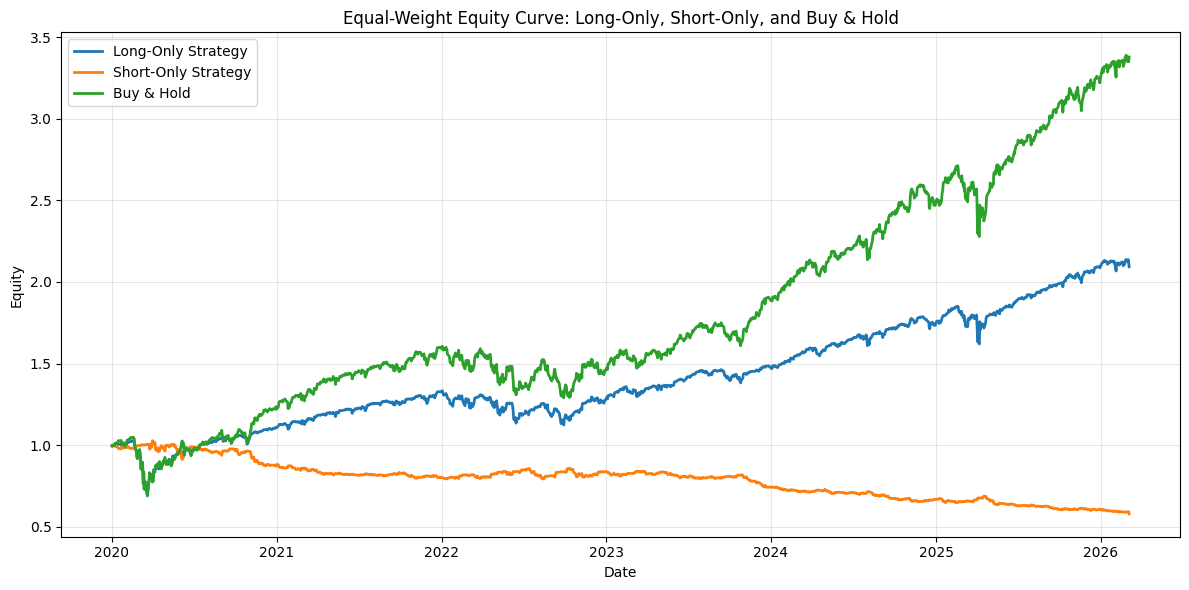

In [22]:
import matplotlib.pyplot as plt

def print_backtest_headline(summary_df, label):
    symbol_outperform_rate = float(summary_df.loc[0, "symbol_outperform_rate"])
    strategy_equal_weight_cum_return = float(summary_df.loc[0, "strategy_equal_weight_cum_return"])
    buy_hold_equal_weight_cum_return = float(summary_df.loc[0, "buy_hold_equal_weight_cum_return"])
    backtest_symbol_count = int(summary_df.loc[0, "backtest_symbols"])
    mean_active_positions = float(summary_df.loc[0, "mean_active_positions"])
    print(
        f"{label}: beat buy-and-hold on {symbol_outperform_rate:.1%} of symbols "
        f"({backtest_symbol_count} symbols) from 2020-01-01 onward."
    )
    print(
        f"{label}: equal-weight cumulative return {strategy_equal_weight_cum_return:.1%} | "
        f"buy-and-hold {buy_hold_equal_weight_cum_return:.1%} | "
        f"mean active positions {mean_active_positions:.1f}"
    )

print_backtest_headline(long_only_backtest_summary_df, "Long-only")
print_backtest_headline(short_only_backtest_summary_df, "Short-only")

long_plot_df = long_only_backtest_daily_equal_weight_df.copy()
long_plot_df["date"] = pd.to_datetime(long_plot_df["date"], errors="coerce")
long_plot_df = long_plot_df.dropna(subset=["date"]).sort_values("date")
short_plot_df = short_only_backtest_daily_equal_weight_df.copy()
short_plot_df["date"] = pd.to_datetime(short_plot_df["date"], errors="coerce")
short_plot_df = short_plot_df.dropna(subset=["date"]).sort_values("date")

plot_df = long_plot_df[["date", "buy_hold_equity"]].merge(
    short_plot_df[["date", "strategy_equity"]].rename(columns={"strategy_equity": "short_strategy_equity"}),
    on="date",
    how="inner",
)
plot_df = plot_df.merge(
    long_plot_df[["date", "strategy_equity"]].rename(columns={"strategy_equity": "long_strategy_equity"}),
    on="date",
    how="inner",
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(plot_df["date"], plot_df["long_strategy_equity"], label="Long-Only Strategy", linewidth=2.0)
ax.plot(plot_df["date"], plot_df["short_strategy_equity"], label="Short-Only Strategy", linewidth=2.0)
ax.plot(plot_df["date"], plot_df["buy_hold_equity"], label="Buy & Hold", linewidth=2.0)
ax.set_title("Equal-Weight Equity Curve: Long-Only, Short-Only, and Buy & Hold")
ax.set_xlabel("Date")
ax.set_ylabel("Equity")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


In [23]:
if "long_only_backtest_stateful_df" not in globals() or "short_only_backtest_stateful_df" not in globals():
    if "entry_exit_backtest_payload" in globals():
        long_only_backtest_stateful_df = entry_exit_backtest_payload["long_only_stateful_df"].copy()
        short_only_backtest_stateful_df = entry_exit_backtest_payload["short_only_stateful_df"].copy()
    else:
        raise RuntimeError("Run the stateful backtest cell first so entry_exit_backtest_payload is available.")

def summarize_signal_probability_alignment(stateful_df, *, signal_label, probability_col, side_label):
    signal_df = stateful_df[stateful_df["trade_signal"] == signal_label].copy()
    if signal_df.empty:
        return pd.DataFrame(), pd.DataFrame()

    signal_df["side_realized_return"] = pd.to_numeric(signal_df["next_return"], errors="coerce").fillna(0.0)
    if side_label == "short":
        signal_df["side_realized_return"] = -signal_df["side_realized_return"]
    signal_df["positive_outcome"] = signal_df["side_realized_return"] > 0.0

    corr_summary_df = pd.DataFrame(
        [
            {
                "side": side_label,
                "signal": signal_label,
                "rows": int(len(signal_df)),
                "probability_col": probability_col,
                "pearson": float(signal_df[probability_col].corr(signal_df["side_realized_return"], method="pearson")),
                "spearman": float(signal_df[probability_col].corr(signal_df["side_realized_return"], method="spearman")),
                "mean_probability": float(signal_df[probability_col].mean()),
                "mean_side_realized_return": float(signal_df["side_realized_return"].mean()),
                "hit_rate": float(signal_df["positive_outcome"].mean()),
            }
        ]
    )

    bucket_count = min(10, int(signal_df[probability_col].nunique()))
    if bucket_count >= 2:
        signal_df["prob_bucket"] = pd.qcut(signal_df[probability_col], q=bucket_count, duplicates="drop")
        bucket_summary_df = (
            signal_df.groupby("prob_bucket", observed=False, as_index=False)
            .agg(
                rows=(probability_col, "size"),
                mean_probability=(probability_col, "mean"),
                mean_side_realized_return=("side_realized_return", "mean"),
                median_side_realized_return=("side_realized_return", "median"),
                hit_rate=("positive_outcome", "mean"),
            )
        )
        bucket_summary_df.insert(0, "side", side_label)
    else:
        bucket_summary_df = pd.DataFrame()

    return corr_summary_df, bucket_summary_df


long_signal_corr_df, long_signal_bucket_df = summarize_signal_probability_alignment(
    long_only_backtest_stateful_df,
    signal_label="buy",
    probability_col="entry_prob_buy",
    side_label="long",
)
short_signal_corr_df, short_signal_bucket_df = summarize_signal_probability_alignment(
    short_only_backtest_stateful_df,
    signal_label="short",
    probability_col="entry_prob_short",
    side_label="short",
)

signal_probability_corr_df = pd.concat([long_signal_corr_df, short_signal_corr_df], ignore_index=True)
signal_probability_bucket_df = pd.concat([long_signal_bucket_df, short_signal_bucket_df], ignore_index=True)

display(signal_probability_corr_df)
display(signal_probability_bucket_df)


,side,signal,rows,probability_col,pearson,spearman,mean_probability,mean_side_realized_return,hit_rate
0,long,buy,15688,entry_prob_buy,0.011470,0.006849,0.868434,0.001096,0.523649
1,short,short,13662,entry_prob_short,-0.004073,0.000173,0.848446,-0.001593,0.471527


,side,prob_bucket,rows,mean_probability,mean_side_realized_return,median_side_realized_return,hit_rate
0,long,"(0.499, 0.612]",1569,0.554904,0.000779,0.000616,0.512428
1,long,"(0.612, 0.727]",1569,0.668965,0.000010,0.000000,0.499681
2,long,"(0.727, 0.825]",1569,0.777266,0.001319,0.000983,0.526450
3,long,"(0.825, 0.896]",1568,0.862134,0.001648,0.001324,0.533163
4,long,"(0.896, 0.941]",1569,0.920733,0.001202,0.000973,0.525175
5,long,"(0.941, 0.966]",1569,0.954869,0.001497,0.001418,0.536010
6,long,"(0.966, 0.981]",1568,0.974502,0.000675,0.000474,0.508929
7,long,"(0.981, 0.989]",1569,0.985618,0.001696,0.001243,0.532186
8,long,"(0.989, 0.993]",1569,0.991061,0.002505,0.001615,0.551944
9,long,"(0.993, 0.997]",1569,0.994346,-0.000367,0.000361,0.510516


In [24]:
import torch

from analysis.context_family_classifier_backtest import build_context_family_daily_state_panel


if "long_only_backtest_stateful_df" not in globals() or "short_only_backtest_stateful_df" not in globals():
    if "entry_exit_backtest_payload" in globals():
        long_only_backtest_stateful_df = entry_exit_backtest_payload["long_only_stateful_df"].copy()
        short_only_backtest_stateful_df = entry_exit_backtest_payload["short_only_stateful_df"].copy()
    else:
        raise RuntimeError("Run the stateful backtest cell first so entry_exit_backtest_payload is available.")


@torch.no_grad()
def score_daily_entry_return_head(model, frame, *, batch_size=32):
    rows = []
    model.eval()

    for start in range(0, len(frame), batch_size):
        batch = frame.iloc[start:start + batch_size].reset_index(drop=True)
        market_tensor = torch.tensor(
            batch[STATE_MARKET_COLS].to_numpy(dtype=np.float32),
            dtype=torch.float32,
            device=device,
        )
        fundamental_tensor = torch.tensor(
            batch[STATE_FUNDAMENTAL_COLS].to_numpy(dtype=np.float32),
            dtype=torch.float32,
            device=device,
        )
        macro_tensor = torch.tensor(
            batch[STATE_MACRO_COLS].to_numpy(dtype=np.float32),
            dtype=torch.float32,
            device=device,
        )

        state_embeddings, _ = model.forward_state(
            batch["text"].tolist(),
            market_tensor,
            fundamental_tensor,
            macro_tensor,
        )
        entry_logits, entry_return_pred, entry_signed_return_pred, entry_duration_pred = model.predict_entry_outcomes(state_embeddings)
        action_probs = torch.softmax(entry_logits, dim=1).detach().cpu().numpy()
        entry_return_pred = entry_return_pred.detach().cpu().numpy()
        entry_signed_return_pred = entry_signed_return_pred.detach().cpu().numpy()
        entry_duration_pred = entry_duration_pred.detach().cpu().numpy()

        for row, prob_values, return_pred, signed_return_pred, duration_pred in zip(
            batch.to_dict(orient="records"),
            action_probs,
            entry_return_pred,
            entry_signed_return_pred,
            entry_duration_pred,
        ):
            rows.append(
                {
                    "date": row["date"],
                    "date_text": row["date_text"],
                    "symbol": row["symbol"],
                    "entry_prob_buy": float(prob_values[0]),
                    "entry_prob_short": float(prob_values[1]),
                    "entry_pred_trade_return_pct": float(return_pred),
                    "entry_pred_signed_trade_return_pct": float(signed_return_pred),
                    "entry_pred_duration_pct": float(duration_pred),
                }
            )

    return pd.DataFrame(rows)


def summarize_return_head_alignment(frame, *, side_label, prediction_col):
    if frame.empty:
        return pd.DataFrame(), pd.DataFrame()

    corr_summary_df = pd.DataFrame(
        [
            {
                "side": side_label,
                "rows": int(len(frame)),
                "prediction_col": prediction_col,
                "pearson": float(frame[prediction_col].corr(frame["side_realized_return"], method="pearson")),
                "spearman": float(frame[prediction_col].corr(frame["side_realized_return"], method="spearman")),
                "mean_prediction": float(frame[prediction_col].mean()),
                "mean_side_realized_return": float(frame["side_realized_return"].mean()),
                "hit_rate": float((frame["side_realized_return"] > 0.0).mean()),
            }
        ]
    )

    bucket_count = min(10, int(frame[prediction_col].nunique()))
    if bucket_count >= 2:
        bucketed = frame.copy()
        bucketed["prediction_bucket"] = pd.qcut(bucketed[prediction_col], q=bucket_count, duplicates="drop")
        bucket_summary_df = (
            bucketed.groupby("prediction_bucket", observed=False, as_index=False)
            .agg(
                rows=(prediction_col, "size"),
                mean_prediction=(prediction_col, "mean"),
                mean_side_realized_return=("side_realized_return", "mean"),
                median_side_realized_return=("side_realized_return", "median"),
                hit_rate=("side_realized_return", lambda values: float((pd.Series(values) > 0.0).mean())),
            )
        )
        bucket_summary_df.insert(0, "side", side_label)
    else:
        bucket_summary_df = pd.DataFrame()

    return corr_summary_df, bucket_summary_df


daily_state_backtest_df, _, _, _ = build_context_family_daily_state_panel(
    universe_df,
    price_frames,
    start_date="2020-01-01",
    end_date=None,
)
for col in [*STATE_MARKET_COLS, *STATE_FUNDAMENTAL_COLS, *STATE_MACRO_COLS]:
    if col in daily_state_backtest_df.columns:
        daily_state_backtest_df[col] = pd.to_numeric(daily_state_backtest_df[col], errors="coerce").fillna(0.0)

daily_entry_return_scores_df = score_daily_entry_return_head(
    text_mtl_model,
    daily_state_backtest_df,
    batch_size=training_cfg["batch_size"],
)

long_return_signal_df = long_only_backtest_stateful_df.merge(
    daily_entry_return_scores_df,
    on=["date", "date_text", "symbol", "entry_prob_buy", "entry_prob_short"],
    how="left",
)
long_return_signal_df = long_return_signal_df[long_return_signal_df["trade_signal"] == "buy"].copy()
long_return_signal_df["side_realized_return"] = pd.to_numeric(long_return_signal_df["next_return"], errors="coerce").fillna(0.0)

short_return_signal_df = short_only_backtest_stateful_df.merge(
    daily_entry_return_scores_df,
    on=["date", "date_text", "symbol", "entry_prob_buy", "entry_prob_short"],
    how="left",
)
short_return_signal_df = short_return_signal_df[short_return_signal_df["trade_signal"] == "short"].copy()
short_return_signal_df["side_realized_return"] = -pd.to_numeric(short_return_signal_df["next_return"], errors="coerce").fillna(0.0)

long_return_head_corr_df, long_return_head_bucket_df = summarize_return_head_alignment(
    long_return_signal_df,
    side_label="long",
    prediction_col="entry_pred_trade_return_pct",
)
short_return_head_corr_df, short_return_head_bucket_df = summarize_return_head_alignment(
    short_return_signal_df,
    side_label="short",
    prediction_col="entry_pred_trade_return_pct",
)

return_head_alignment_corr_df = pd.concat(
    [long_return_head_corr_df, short_return_head_corr_df],
    ignore_index=True,
)
return_head_alignment_bucket_df = pd.concat(
    [long_return_head_bucket_df, short_return_head_bucket_df],
    ignore_index=True,
)

display(return_head_alignment_corr_df)
display(return_head_alignment_bucket_df)


,side,rows,prediction_col,pearson,spearman,mean_prediction,mean_side_realized_return,hit_rate
0,long,15688,entry_pred_trade_return_pct,0.014296,0.014951,0.371923,0.001096,0.523649
1,short,13662,entry_pred_trade_return_pct,-0.021894,-0.013960,0.318340,-0.001593,0.471527


,side,prediction_bucket,rows,mean_prediction,mean_side_realized_return,median_side_realized_return,hit_rate
0,long,"(0.10099999999999999, 0.18]",1569,0.151178,0.001124,0.000418,0.515615
1,long,"(0.18, 0.222]",1569,0.201778,0.001106,0.001223,0.538560
2,long,"(0.222, 0.263]",1569,0.242025,0.000608,0.000781,0.519439
3,long,"(0.263, 0.303]",1568,0.282547,0.000815,0.000878,0.522321
4,long,"(0.303, 0.347]",1569,0.324562,0.000907,0.000132,0.503505
5,long,"(0.347, 0.395]",1569,0.370180,0.001106,0.001012,0.524538
6,long,"(0.395, 0.451]",1568,0.422764,-0.000199,0.000832,0.517857
7,long,"(0.451, 0.517]",1569,0.483273,0.001480,0.001345,0.530274
8,long,"(0.517, 0.605]",1569,0.558084,0.002350,0.001791,0.537922
9,long,"(0.605, 0.892]",1569,0.682816,0.001665,0.001647,0.526450
